# PT3S
Use SIR 3S Modeldata and SIR 3S Results in pure Python.

With pandas, matplotlib and others.

For documentation, test, verification, analysis, reporting, prototyping, play.

## Install Python

Python 3.7 (64-bit) [PTVS 16.6.20100.1-16.0]

## Install PT3S to site-packages

In [1]:
### ggf. Rechte erforderlich:  
### entweder in PowerShell: Start-Process powershell -Verb runAs
### oder RMT WindowsSymbol: Windows PowerShell (Administrator)
### dann (ohne ! in PowerShell auf pip-Verz.):
###!pip uninstall --yes PT3S
###!pip install PT3S --no-cache-dir

## OR use local PT3S under Development

In [2]:
###!pip install -e .

## Logging

In [1]:
import logging
import os
logger = logging.getLogger('PT3S')  

logFileName= r"PT3S.log" 

loglevel = logging.DEBUG
logging.basicConfig(filename=logFileName
                        ,filemode='w'
                        ,level=loglevel
                        ,format="%(asctime)s ; %(name)-60s ; %(levelname)-7s ; %(message)s")    

fileHandler = logging.FileHandler(logFileName)     

logger.addHandler(fileHandler)

consoleHandler = logging.StreamHandler()
consoleHandler.setFormatter(logging.Formatter("%(levelname)-7s ; %(message)s"))
consoleHandler.setLevel(logging.INFO)
logger.addHandler(consoleHandler)

## about from PT3S ... import ... and pip install -e .

In [2]:
#%pwd

In [3]:
# works only if pip install -e .is NOT active:
###from PT3S import Mx,Xm,Rm
# or if subdir is PT3S
#%cd -q ..
# ...
#%cd -q PT3S 

In [4]:
# if pip install -e .IS active
# the local modules can be imported with:
import Mx, Xm, Rm
# if %pwd is local devdir

In [5]:
%run Mx.py -l  -v -m 0 -s getSir3sIDoPKFromSir3sID   

Finding tests in Mx
Finding tests in Mx.__init__
Finding tests in Mx.delFiles
Finding tests in Mx._initWithMx1
Finding tests in Mx._parseMx1
Finding tests in Mx._parseMx2
Finding tests in Mx._buildMxRecordStructUnpackFmtString
Finding tests in Mx._buildMxRecordStructUnpackFmtStringPost
Finding tests in Mx._readMxsFile
Finding tests in Mx._checkMxsVecsFile
Finding tests in Mx._handleMxsVecsFileDeletion
Finding tests in Mx.setResultsToMxsFile
Finding tests in Mx.setResultsToMxsZipFile
Finding tests in Mx.ToH5
Finding tests in Mx.FromH5
Finding tests in Mx.getMxsVecsFileData
Finding tests in Mx.unPackMxsVecsFileDataDf
Finding tests in Mx.getVecAggs
Finding tests in Mx.dumpInMxsFormat
Finding tests in Mx._getMx1DfAsOneString
Finding tests in Mx._getDfAsOneString
Finding tests in Mx._getDfVecAsOneString
Finding tests in Mx.getSir3sIDFromSir3sIDoPK
Finding tests in getMicrosecondsFromRefTime
Finding tests in getTimeFromMicroseconds
Finding tests in getSir3sIDoPKFromSir3sID
Trying:
    import

In [7]:
#%run test.py -l -q -m 0 -t before -u yes -y yes -z yes -w DHNetwork -w LocalHeatingNetwork -w GPipes 

Finding tests in Rm
Finding tests in Rm.readModelAndResult
Finding tests in Rm.pltNetPipes
Finding tests in Rm.pltHP
Finding tests in Rm.pltTC
Finding tests in Rm.__init__
Finding tests in Rm.pltNetDHUS
Finding tests in pltMakeCategoricalColors
Finding tests in pltMakeCategoricalCmap
Trying:
    import pandas as pd
Expecting nothing
ok
Trying:
    import matplotlib
Expecting nothing
ok
Trying:
    import matplotlib.pyplot as plt
Expecting nothing
ok
Trying:
    import matplotlib.gridspec as gridspec
Expecting nothing
ok
Trying:
    import matplotlib.dates as mdates
Expecting nothing
ok
Trying:
    import math
Expecting nothing
ok
Trying:
    try:
      import Rm
    except ImportError:                   
      from PT3S import Rm
Expecting nothing
ok
Trying:
    mx=mxs['DHNetwork'] 
Expecting nothing
ok
Trying:
    sir3sID=mx.getSir3sIDFromSir3sIDoPK('ALLG~~~LINEPACKGEOM') # 'ALLG~~~5151766074450398225~LINEPACKGEOM'
Expecting nothing
ok
Trying:
    plt.close()
Expecting nothing
ok
Tryi

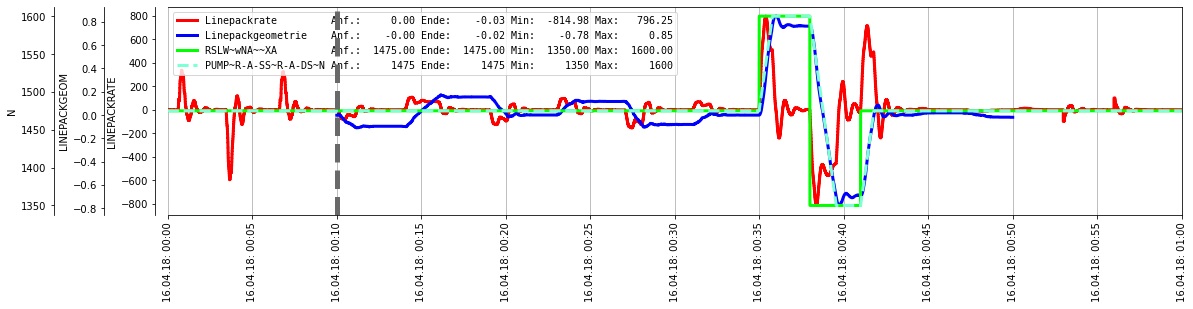

ok


In [8]:
%run Rm.py -l -v -m 0 -s pltTC -y no -z no -w DHNetwork

In [7]:
import doctest
"""
>>> import pandas as pd
>>> pd.__version__
'1.0.4'
"""
doctest.testmod()

TestResults(failed=0, attempted=2)

# ggf. Tests

## Modultests

* die Modultests (-m 1) gehen teilweise von einem definierten "leeren" Ausgangszustand aus: Relikte aus alten Testläufen sollten daher gelöscht werden (-t before), wenn die Modultests vollständig ohne Fehler durchlaufen sollen 
* die Modultests hinterlassen teilweise "Überbleibsel", die explizit gelöscht werden sollten (-t after ==> -t both)
* es müssen nur die Modelle (-w ...) behandelt werden (vorher bzw. nachher aufräumen), die in den Modultests auch verwendet werden
* es werden alle Modultests durchgeführt

nachfolgende Tests erzeugen (trotz -q) auch bei fehlerfreiem Durchlauf eine Ausgabe im Notebook

.
----------------------------------------------------------------------
Ran 1 test in 5.323s

OK
.
----------------------------------------------------------------------
Ran 1 test in 10.143s

OK
.
----------------------------------------------------------------------
Ran 1 test in 2.149s

OK


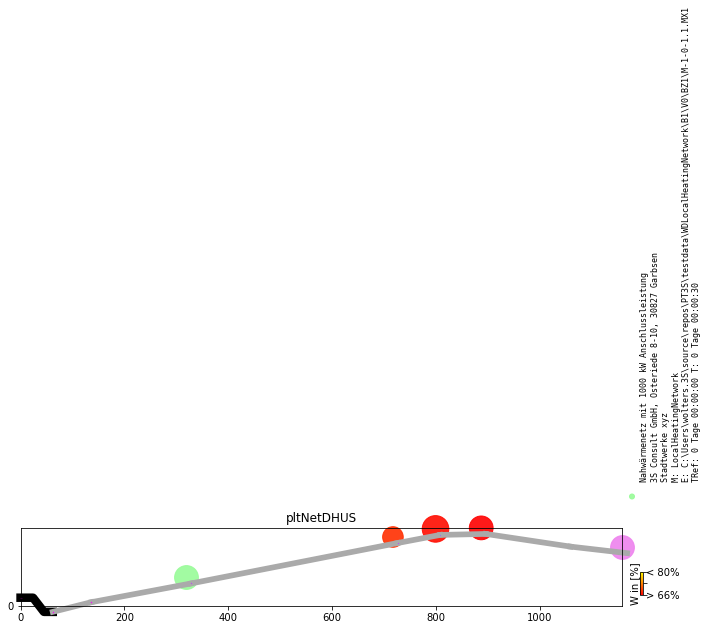

In [8]:
%run test.py -l -q -m 1 -t both \
-w OneLPipe -w LocalHeatingNetwork -w GPipe -w GPipes -w TinyWDN

## Singeltests

* es müssen nur die Modelle (-w ...) behandelt werden, die in den Singletests auch verwendet werden
* vor Singletests könnten die Modultests durchgeführt werden: nachfolgend sind diese ausgeschaltet (-m 0)
* Singletests hinterlassen, so sie nicht selbst aufräumen, "Überbleibsel", die explizit gelöscht werden sollten (-t after)
* Singletests erfahren im Gegensatz zu Modultests ein explizites MockUp außerhalb des eigentlichen Tests; d.h. die Tests beginnen mit "fertigen" Objekten bzw. können zumindest so beginnen; bei Modultests hingegen erfolgt das MockUp immer in der Testsequenz selbst 
* Details zum MockUp können mit -y (kein H5 lesen j/n) und -z (H5 schreiben j/n) angegeben werden
* es können nur die Singletest auf einmal ausgeführt werden, die mit demselben MockUp zurecht kommen
* MockUp hier: kein H5 lesen und kein H5-Schreiben: -y yes -z no 
* nur bei -z yes wird vor dem H5-Schreiben auch Xm.MxSync und .MxAdd durchgeführt
* -s spezifiziert Tests per regExp
* -x spezifiziert Test per regExp die aus der -s-Menge nicht durchzuführen sind

nachfolgende Tests erzeugen (wg. -q) nur bei fehlerfreiem Durchlauf _keine Ausgaben im Notebook

In [9]:
%run test.py -l -q -m 0 \
-s Mx\. -s Xm\. \
-x Mx\.FromH5 \
-x Mx\.ToH5 \
-x Xm\.vKNOTexpEBES \
-x Xm\.vROHRexpEBES \
-x Xm\._vRUES -x Xm\._vRSLW -x Xm\._vRSTN -x Xm\._vRXXX -x Xm\._vREdges \
-x Xm\.MxAdd \
-t both -y yes -z no \
-w OneLPipe -w LocalHeatingNetwork -w GPipe -w GPipes -w TinyWDN

### reiner MockUp-Lauf

* es wird gar kein Test spezifiziert sondern ein reiner MockUp-Lauf
* geeignet z.B. wenn ein MockUp zeitaufwendig ist ...
* ... und ein bestimmter Singletest in einem Modul häufig wiederholt werden muss ...
* ... weil am getesteten Funktionsbereich gearbeitet wird
* MockUp hier: kein H5 lesen aber H5 schreiben: -y yes -z yes
* mit -u wird der reine MockUp-Lauf durchgeführt

nachfolgender Lauf erzeugt (wg. -q) bei fehlerfreiem Durchlauf _keine Ausgaben im Notebook

In [10]:
# test_reinerMockUpLauf
%run test.py -l -q -m 0 -t before \
-u yes \
-y yes -z yes \
-w DHNetwork -w LocalHeatingNetwork -w GPipes 

 ### Singletest basierend auf diesem reinem MockUp-Lauf
 
 * Testläufe können mit H5 lesen (-y no) und kein H5 schreiben (-z no) am Schnellsten durchgeführt werden
 * Singletest und MockUp müssen zueinander passen (d.h. z.B. wenn ein Singletest mit "fertigen" Objekten beginnt müssen diese durch den MockUp bereitgestellt werden)
 * der Entwicklungsstand ebenfalls: die "fertigen" Objekte werden ja zuvor in einem (ggf. reinen MockUp-Lauf) erzeugt und als H5 abgespeichert; mit solchen Singletests kann daher nur gearbeitet werden wenn andere Codeteile entsprechend "durchlaufen"

In [11]:
%run test.py -l -q -m 0 \
-s Xm\.vKNOTexpEBES \
-s Xm\.vROHRexpEBES \
-s Xm\._vRUES -s Xm\._vRSLW -s Xm\._vRSTN -s Xm\._vRXXX -s Xm\._vREdges \
-s Xm\.MxAdd \
-y no -z no \
-w DHNetwork -w LocalHeatingNetwork -w GPipes 

 ### weitere Beispiele für Singletests

Beispiel: durchführen eines einzelnen Tests in Modul Mx über Mx.py

das Testobjekt ist eine Klassen-freie Funktion, die kein Modell-MockUp benötigt

In [12]:
%run Mx.py -l -q -m 0 -s getMicrosecondsFromRefTime 

Beispiel: durchführen eines einzelnen Tests in Modul Xm über Xm.py

das Testobjekt ist eine Klassen-Funktion, welche die angegebenen Modell-MockUps benötigt

In [13]:
%run Xm.py -l -q -m 0 -s Xm\.constructShortestPathFromNodeList -t both -y yes -z no -w GPipes -w LocalHeatingNetwork

Beispiel: weitere Singletests

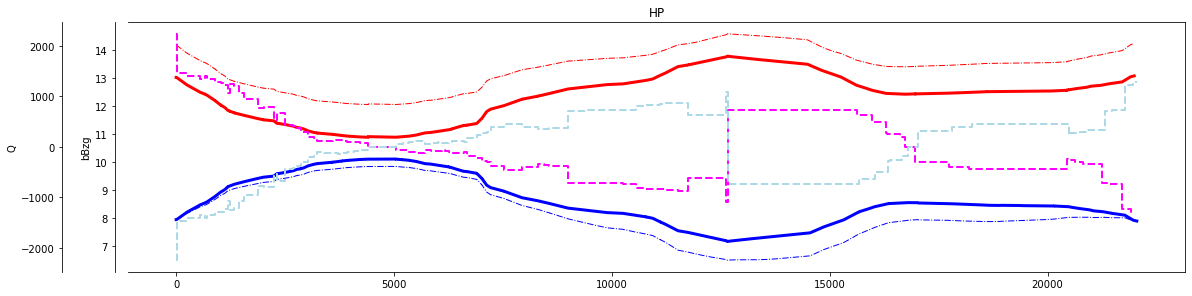

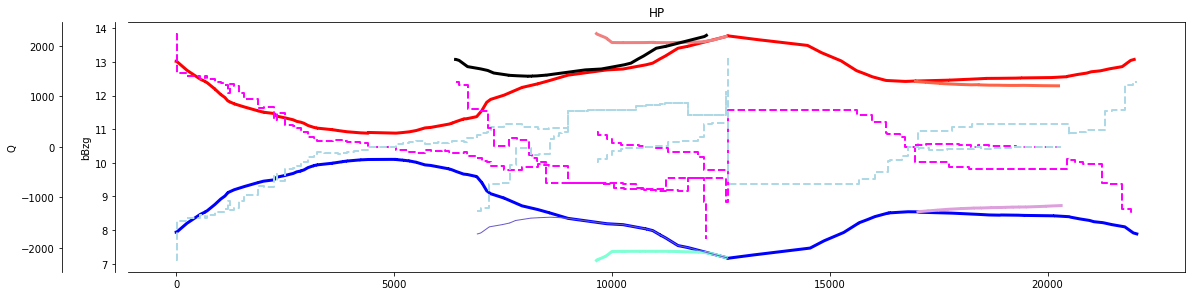

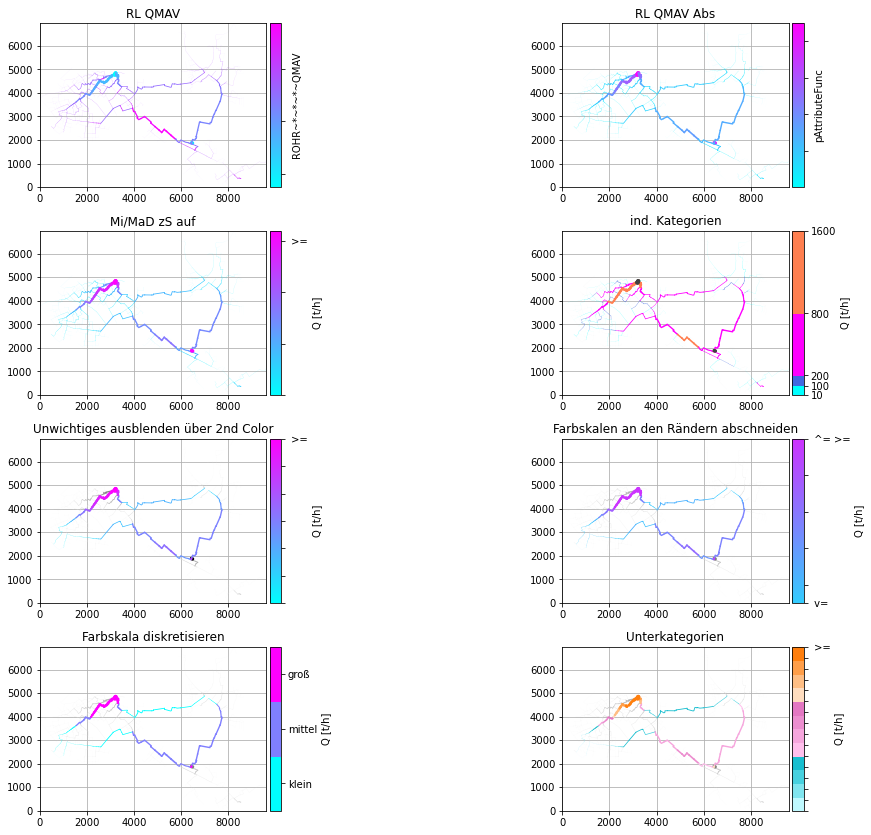

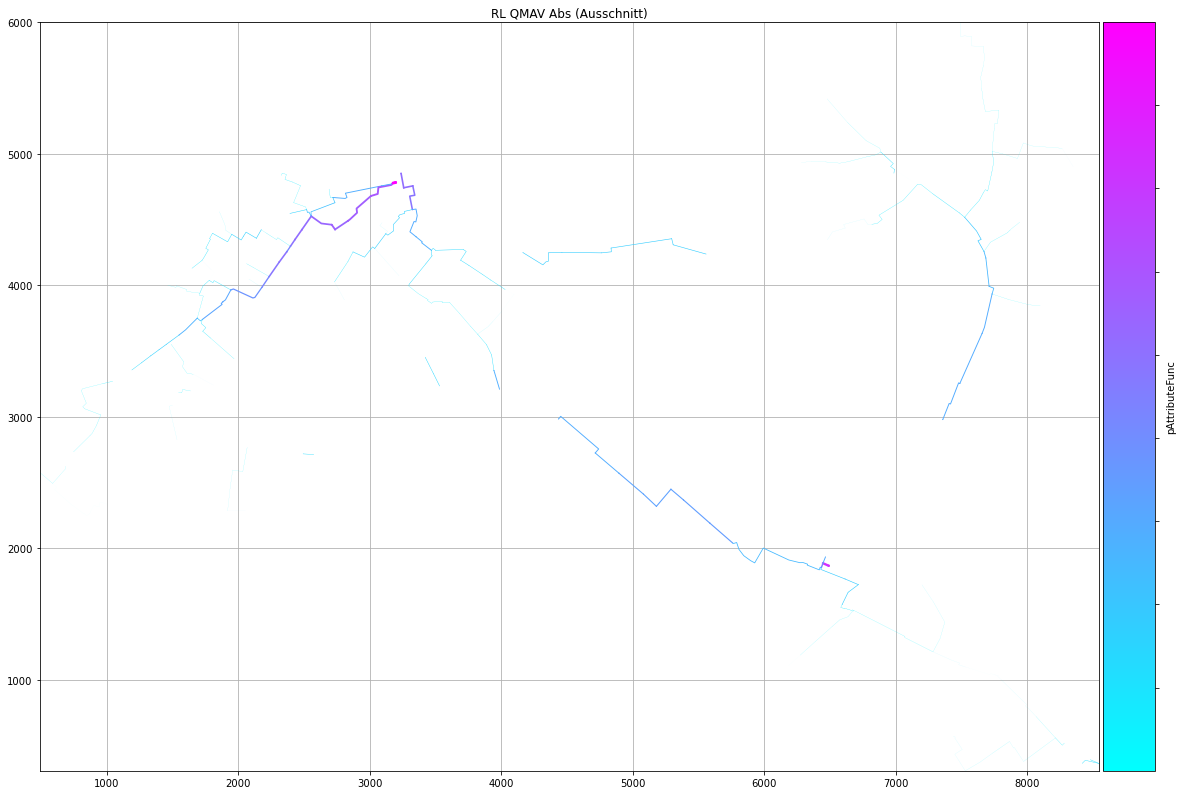

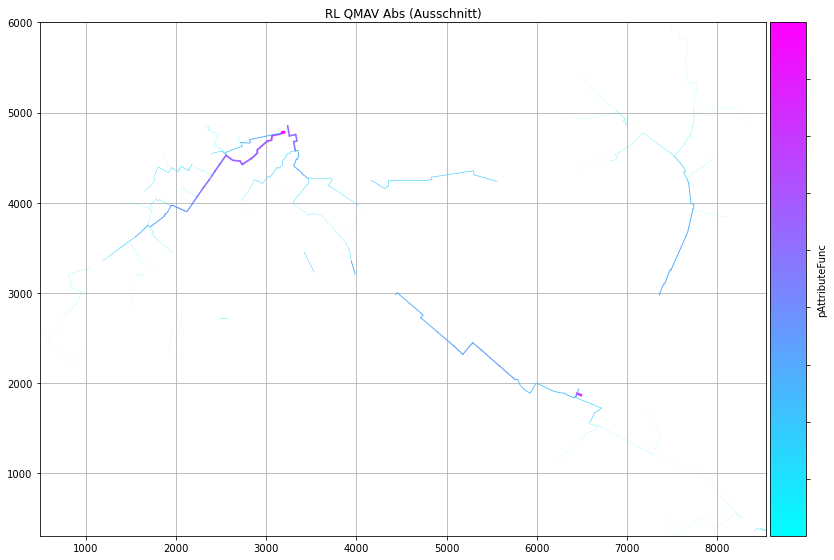

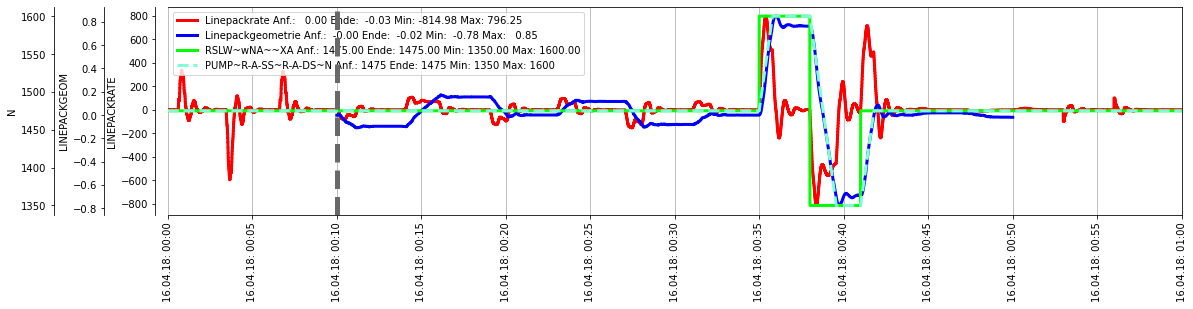

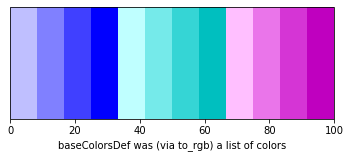

In [14]:
%run Rm.py -l -q -m 0 \
-s pltMakeCategoricalColors \
-s pltMakeCategoricalCmap \
-s Rm\. \
-y no -z no \
-w DHNetwork

## Modultests mit anderen Daten

.
----------------------------------------------------------------------
Ran 1 test in 5.247s

OK
.
----------------------------------------------------------------------
Ran 1 test in 15.286s

OK
.
----------------------------------------------------------------------
Ran 1 test in 2.660s

OK


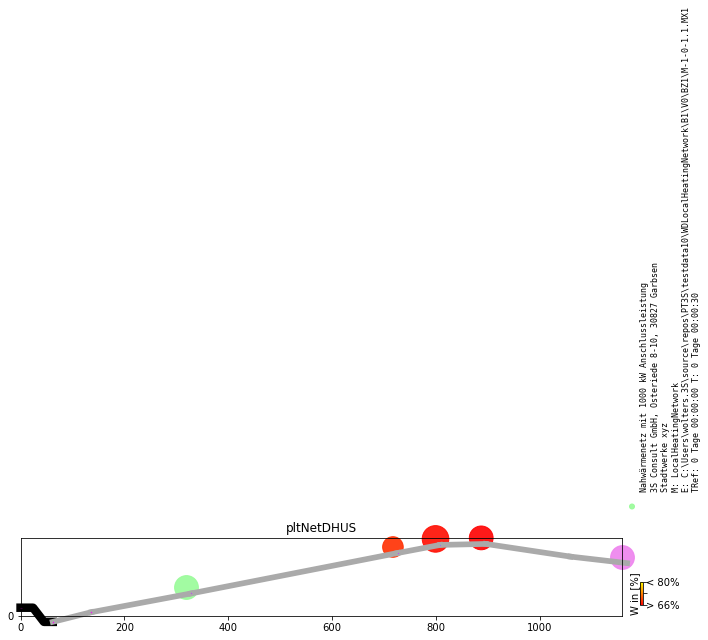

In [15]:
%run test.py -l -q -m 1 -t both --testDir testdata10 

.
----------------------------------------------------------------------
Ran 1 test in 5.070s

OK
.
----------------------------------------------------------------------
Ran 1 test in 11.079s

OK
.
----------------------------------------------------------------------
Ran 1 test in 2.338s

OK


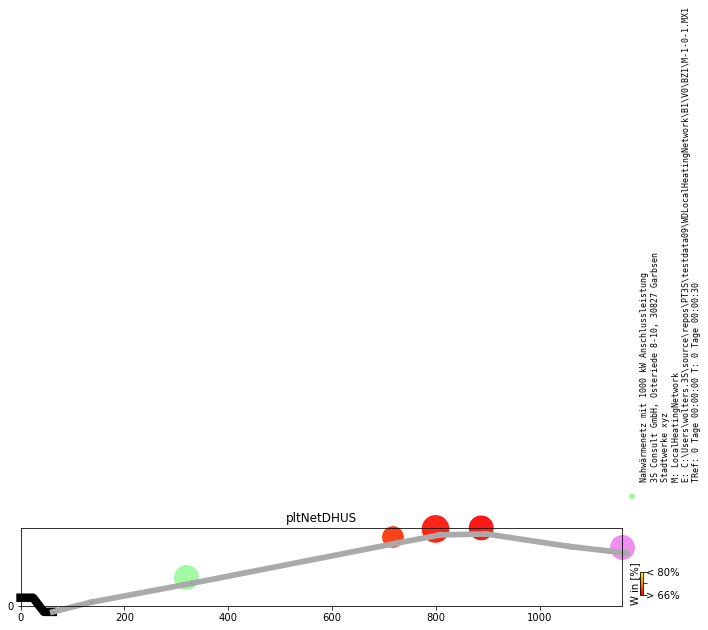

In [16]:
%run test.py -l -q -m 1 -t both --testDir testdata09 --dotResolution NONE

# Modell und Ergebnisse laden und nutzen

In [17]:
import pandas as pd
import numpy as np
import scipy
import networkx as nx

## Modell

In [18]:
path='.'
xmlFile=os.path.join(path,'testdata\LocalHeatingNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)

In [19]:
vVBEL=xm.dataFrames['vVBEL']
vVBEL.filter(items=['BESCHREIBUNG','NAME_i','NAME_k','LAYR','L','D']).sort_index(level=1)

BESCHREIBUNG       NAME_i  NAME_k             LAYR       L      D
OBJTYPE OBJID                                                                                                  
ROHR    4613782368750024999                           None       R-K004  R-K005       [Rücklauf]   88.02  107.1
        4614949065966596185                           None       V-K002  V-K003        [Vorlauf]  405.96  107.1
        4637102239750163477                           None       R-K003  R-K004       [Rücklauf]   83.55  107.1
FWVB    4643800032883366034                              1       V-K002  R-K002  [Kundenanlagen]       0    NaN
VENT    4678923650983295610                           None          V-1     V-L        [Vorlauf]       0    150
FWVB    4704603947372595298                              3       V-K004  R-K004  [Kundenanlagen]       0    NaN
ROHR    4713733238627697042                           None       V-K004  V-K005        [Vorlauf]   88.02  107.1
        4769996343148550485                           None          R-L  R-K000       [Rücklauf]   73.42  160.3
        4789218195240364437                           None       V-K001  V-K002        [Vorlauf]  195.53  107.1
KLAP    4801110583764519435                           None           R2      R3       [Rücklauf]       0     80
VENT    4897018421024717974                           None          R-L     R-1       [Rücklauf]       0    150
ROHR    4939422678063487923                           None          V-L  V-K000        [Vorlauf]    68.6  160.3
        4945727430885351042                           None       R-K006  R-K007       [Rücklauf]  109.77  107.1
        4984202422877610920                           None       V-K000  V-K001        [Vorlauf]    76.4  107.1
PGRP    4986517622672493603                   Pumpengruppe          R-1      R3               []       0    NaN
ROHR    5037777106796980248                           None       V-K003  V-K004        [Vorlauf]   83.55  107.1
FWVB    5121101823283893406                              4       V-K005  R-K005  [Kundenanlagen]       0    NaN
ROHR    5123819811204259837                           None       V-K005  V-K006        [Vorlauf]  164.91  107.1
        5266224553324203132                           None       R-K001  R-K002       [Rücklauf]  195.53  107.1
        5379365049009065623                           None       R-K002  R-K003       [Rücklauf]  405.96  107.1
FWVB    5400405917816384862                              5       V-K007  R-K007  [Kundenanlagen]       0    NaN
PUMP    5481331875203087055                    Umwälzpumpe          R-1      R2       [Rücklauf]       0    NaN
VENT    5525310316015533093                           None  PKON-Knoten     R-1       [Rücklauf]       0     50
ROHR    5611703699850694889                           None       R-K005  R-K006       [Rücklauf]  164.91  107.1
        5620197984230756681                           None       V-K006  V-K007        [Vorlauf]  109.77  107.1
FWES    5638756766880678918  BHKW - Modul - 1000 kW therm.           R3     V-1        [Vorlauf]       0     80
ROHR    5647213228462830353                           None       R-K000  R-K001       [Rücklauf]    76.4  107.1
FWVB    5695730293103267172                              2       V-K003  R-K003  [Kundenanlagen]       0    NaN

In [20]:
vVBEL.dtypes

BESCHREIBUNG    object
IDREFERENZ      object
tk              object
NAME_i          object
CONT_i          object
CONT_VKNO_i     object
Z_i             object
pk_i            object
NAME_k          object
CONT_k          object
CONT_VKNO_k     object
Z_k             object
pk_k            object
LAYR            object
L               object
D               object
dtype: object

In [21]:
[viewOrTable for viewOrTable in sorted(xm.dataFrames.keys())]

['AGSN',
 'ALLG',
 'ALLG_BZ',
 'ARRW',
 'ATMO',
 'AVOS',
 'AVOS_ROWS',
 'BZAG',
 'BZAG_BZ',
 'CONT',
 'DATENEBENE',
 'DPGR',
 'DPGR_BZ',
 'DPGR_DPKT',
 'DPKT',
 'DRNP',
 'DTRO',
 'DTRO_ROWD',
 'EBES',
 'EBES_BZ',
 'ELEMENTQUERY',
 'ETAM',
 'ETAM_ROWS',
 'ETAR',
 'ETAR_ROWS',
 'ETAU',
 'ETAU_ROWS',
 'FSTF',
 'FWBZ',
 'FWES',
 'FWES_BZ',
 'FWVB',
 'FWVB_BZ',
 'GMIX',
 'GRAV',
 'GTXT',
 'KLAP',
 'KLAP_BZ',
 'KNOT',
 'KNOT_BZ',
 'LAYR',
 'LFAL',
 'LFAL_BZ',
 'LFKT',
 'LFKT_ROWT',
 'LTGR',
 'MAPG',
 'MAPG_ROWS',
 'MODELL',
 'NRCV',
 'PARI',
 'PARI_BZ',
 'PARV',
 'PARZ',
 'PARZ_BZ',
 'PGPR',
 'PGRP',
 'PGRP_BZ',
 'PGRP_PUMP',
 'PGRP_PUMP_BZ',
 'PHI1',
 'PHI1_ROWT',
 'PHI2',
 'PHI2_ROWS',
 'PHIV',
 'PHIV_ROWS',
 'PUMD',
 'PUMD_ROWT',
 'PUMK',
 'PUMK_ROWS',
 'PUMP',
 'PUMP_BZ',
 'PVAR',
 'PVAR_ROWT',
 'PZON',
 'PZVR',
 'PZVR_BZ',
 'QVAR',
 'QVAR_ROWT',
 'RART',
 'RART_BZ',
 'RCON',
 'RECT',
 'REGP',
 'ROHR',
 'ROHR_BZ',
 'RPFL',
 'RPLAN',
 'SIRGRAF',
 'SOKO',
 'SPLZ',
 'STOF',
 'STOF_ROWS',
 '

## Ergebnisse

In [22]:
# Weg A um an Ergebnisse zu kommen: 
# Modell(-Views) um MX-Ergebnisse ergaenzen; MX-Ergebnissatz des Modells wird implizit gelesen und returned
mx=xm.MxSync()

In [23]:
# Weg B um an Ergebnisse zu kommen:
# einen MX-Ergebnissatz voellig unabhaengig von einem Modell lesen
# z.B. den MX-Ergebnissatz des Modells ...
(wDir,modelDir,modelName,mx1File)=xm.getWDirModelDirModelName()  
# ... lesen
mx=Mx.Mx(mx1File=mx1File)

### Non-Vector

In [24]:
mx.df.filter(items=['ALLG~~~4639827058859487185~SNAPSHOTTYPE','KNOT~V-L~~5736262931552588702~PH'])

,ALLG~~~4639827058859487185~SNAPSHOTTYPE,KNOT~V-L~~5736262931552588702~PH
2004-09-22 08:30:00+00:00,b'STAT',4.125885
2004-09-22 08:30:15+00:00,b'TIME',3.161918
2004-09-22 08:30:30+00:00,b'TIME',2.597010
2004-09-22 08:30:45+00:00,b'TIME',2.207441
2004-09-22 08:31:00+00:00,b'TIME',4.225861


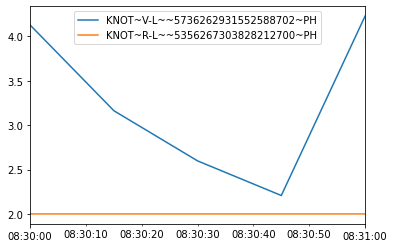

In [25]:
mx.df.filter(regex='^KNOT').filter(regex='PH$').plot()

### Vector

In [26]:
timesReq=mx.df.index.tolist()
mxVecsFileData=mx.getMxsVecsFileData(timesReq)
for vecsFileResult in mxVecsFileData:
    print(vecsFileResult.index)

DatetimeIndex(['2004-09-22 08:30:00+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:30:15+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:30:30+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:30:45+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:31:00+00:00'], dtype='datetime64[ns, UTC]', freq=None)


In [27]:
vecsFileResult.filter(regex='^ROHR').filter(regex='^(?!.*VEC)')

,ROHR~*~*~*~QMI,ROHR~*~*~*~VI,ROHR~*~*~*~VK,ROHR~*~*~*~QMK,ROHR~*~*~*~QMAV,ROHR~*~*~*~VAV,ROHR~*~*~*~IAKTIV
2004-09-22 08:31:00+00:00,"(-8.509474754333496, 19.05978012084961, -15.378900527954102, 8.509475708007812, -22.987945556640625, 22.987945556640625, 22.987947463989258, -3.928166389465332, 22.987947463989258, 15.378901481628418, 3.928166627883911, -22.987945556640625, -19.059778213500977, -3.928166389465332, 3.928166627883911, -22.987945556640625)","(-0.26672810316085815, 0.6085612773895264, -0.4820491075515747, 0.2716997563838959, -0.3216458857059479, 0.7339840531349182, 0.32764118909835815, -0.12312773615121841, 0.7339840531349182, 0.49103420972824097, 0.12542276084423065, -0.7205533981323242, -0.597425639629364, -0.12312772870063782, 0.12542276084423065, -0.7205533981323242)","(-0.26672810316085815, 0.6085612773895264, -0.4820491075515747, 0.2716997563838959, -0.3216458857059479, 0.7339840531349182, 0.32764118909835815, -0.12312773615121841, 0.7339840531349182, 0.49103420972824097, 0.12542276084423065, -0.7205533981323242, -0.597425639629364, -0.12312772870063782, 0.12542276084423065, -0.7205533981323242)","(-8.509474754333496, 19.05978012084961, -15.378900527954102, 8.509475708007812, -22.987945556640625, 22.987945556640625, 22.987947463989258, -3.928166389465332, 22.987947463989258, 15.378901481628418, 3.928166627883911, -22.987945556640625, -19.059778213500977, -3.928166389465332, 3.928166627883911, -22.987945556640625)","(-8.509474754333496, 19.05978012084961, -15.378900527954102, 8.509475708007812, -22.987945556640625, 22.987945556640625, 22.987947463989258, -3.928166389465332, 22.987947463989258, 15.378901481628418, 3.928166627883911, -22.987945556640625, -19.059778213500977, -3.928166389465332, 3.928166627883911, -22.987945556640625)","(-0.26672810316085815, 0.6085612773895264, -0.4820491075515747, 0.2716997563838959, -0.3216458857059479, 0.7339840531349182, 0.32764118909835815, -0.12312773615121841, 0.7339840531349182, 0.49103420972824097, 0.12542276084423065, -0.7205533981323242, -0.597425639629364, -0.12312772870063782, 0.12542276084423065, -0.7205533981323242)","(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)"


In [28]:
vecsFileResult.filter(regex='^KNOT')

,KNOT~*~*~*~P,KNOT~*~*~*~HMAX_INST,KNOT~*~*~*~H,KNOT~*~*~*~T,KNOT~*~*~*~PDAMPF,KNOT~*~*~*~HMIN_INST,KNOT~*~*~*~PMIN_INST,KNOT~*~*~*~RHO,KNOT~*~*~*~PMAX_INST,KNOT~*~*~*~WALTER,KNOT~*~*~*~PH,KNOT~*~*~*~IAKTIV
2004-09-22 08:31:00+00:00,"(3.3029706478118896, 5.085822105407715, 5.1833600997924805, 5.221471309661865, 3.043287992477417, 3.2835655212402344, 3.004936695098877, 5.41128396987915, 5.225996017456055, 3.30965518951416, 5.391567230224609, 3.0001327991485596, 3.1414403915405273, 4.9259467124938965, 3.0, 4.9194440841674805, 3.3146584033966064, 4.916575908660889, 3.3126587867736816, 3.0, 4.945080280303955, 5.225861072540283, 4.914667129516602)","(2.3029708862304688, 4.085822105407715, 4.1833600997924805, 4.221471309661865, 2.043287992477417, 2.2835655212402344, 2.004936695098877, 4.41128396987915, 4.225996017456055, 2.30965518951416, 4.391567230224609, 2.0001327991485596, 2.1414403915405273, 3.9259469509124756, 2.0, 3.9194438457489014, 2.3146584033966064, 3.9165759086608887, 2.3126590251922607, 2.0, 3.945080280303955, 4.225861072540283, 3.9146668910980225)","(2.3029706478118896, 4.085822105407715, 4.1833600997924805, 4.221471309661865, 2.043287992477417, 2.2835655212402344, 2.004936695098877, 4.41128396987915, 4.225996017456055, 2.30965518951416, 4.391567230224609, 2.0001327991485596, 2.1414403915405273, 3.9259469509124756, 2.0, 3.9194438457489014, 2.3146584033966064, 3.9165759086608887, 2.3126587867736816, 2.0, 3.945080280303955, 4.225861072540283, 3.9146668910980225)","(60.0, 90.0, 90.0, 90.0, 60.0, 60.0, 60.0, 60.0, 90.0, 60.0, 60.0, 60.0, 60.0, 90.0, 60.0, 90.0, 60.0, 90.0, 60.0, 60.0, 90.0, 90.0, 90.0)","(0.19919998943805695, 0.7010999917984009, 0.7010999917984009, 0.7010999917984009, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.19919998943805695, 0.7010999917984009, 0.7010999917984009, 0.7010999917984009)","(2.0520997047424316, 2.18302845954895, 2.2000110149383545, 2.206646680831909, 2.007716655731201, 2.0488646030426025, 2.0009095668792725, 2.2489230632781982, 2.207463264465332, 2.0532398223876953, 2.234365463256836, 2.000021457672119, 2.0251383781433105, 2.156905174255371, 2.0, 2.1558215618133545, 2.054124116897583, 2.155325412750244, 2.0537707805633545, 2.0, 2.160024881362915, 2.2074413299560547, 2.1549954414367676)","(3.0520997047424316, 3.18302845954895, 3.2000110149383545, 3.206646680831909, 3.007716655731201, 3.0488646030426025, 3.0009095668792725, 3.2489230632781982, 3.207463264465332, 3.0532398223876953, 3.234365463256836, 3.000021457672119, 3.0251383781433105, 3.156905174255371, 3.0, 3.1558215618133545, 3.054124116897583, 3.155325412750244, 3.0537707805633545, 3.0, 3.160024881362915, 3.2074413299560547, 3.1549954414367676)","(983.7000122070312, 965.7000122070312, 965.7000122070312, 965.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 983.7000122070312, 965.7000122070312, 965.7000122070312, 965.7000122070312)","(3.3029708862304688, 5.085822105407715, 5.1833600997924805, 5.221471309661865, 3.043287992477417, 3.2835655212402344, 3.004936695098877, 5.41128396987915, 5.225996017456055, 3.30965518951416, 5.391567230224609, 3.0001327991485596, 3.1414403915405273, 4.9259467124938965, 3.0, 4.9194440841674805, 3.3146584033966064, 4.916575908660889, 3.3126590251922607, 3.0, 4.945080280303955, 5.225861072540283, 4.914667129516602)","(0.20900359749794006, 0.16107229888439178, 0.08707356452941895, 0.058159828186035156, 0.40391021966934204, 0.20748744904994965, 0.4333629012107849, 0.49676936864852905, 0.0, 0.286059081

### Vector: Aggregate
- TIME: MXS: SIR 3S t=0-Ergebnis als instat. AB (kein Aggregat) - implizit von _readMxsFile
- TMIN,TMAX: MXS: SIR 3S Min./Max. - implizit von _readMxsFile  
- or Aggregates from 2 Times: MIN,MAX,... - implizit von getVecAggs

In [29]:
mx.dfVecAggs

0           1             2           3           4           5           6           7           8           9          10          11          12          13          14          15          16          17          18          19          20          21          22          23          24          25          26          27          28          29          30          31
TYPE Sir3sID                 TIMESTAMPL          TIMESTAMPR                                                                                                                                                                                                                                                                                                                                                                                                           
TIME ROHR~*~*~*~QMI          2004-09-22 08:30:00 2004-09-22 08:30:00   -8.509475   19.059780 -1.537890e+01    8.509476  -22.987946   22.987946   22.987947   -3.928166   22.987947   15.378901    3.928167  -22.987946  -19.059778   -3.928166    3.928167  -22.987946         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN
     KNOT~*~*~*~P            2004-09-22 08:30:00 2004-09-22 08:30:00    3.302971    4.985846  5.083384e+00    5.121495    3.043288    3.283566    3.004937    5.311307    5.126019    3.309655    5.291591    3.000133    3.141440    4.825970    3.000000    4.819467    3.314658    4.816599    3.312659    3.000000    4.845104    5.125885    4.814690         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN
     FWES~*~*~*~QM           2004-09-22 08:30:00 2004-09-22 08:30:00   22.987947         NaN           NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN
     KNOT~*~*~*~HMAX_INST    2004-09-22 08:30:00 2004-09-22 08:30:00    2.302971    3.985846  4.083384e+00    4.121495    2.043288    2.283566    2.004937    4.311307    4.126019    2.309655    4.291591    2.000133    2.141440    3.825970    2.000000    3.819467    2.314658    3.816599    2.312659    2.000000    3.845104    4.125885    3.814690         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN
     ROHR~*~*~*~PVECMIN_INST 2004-09-22 08:30:00 2004-09-22 08:30:00    3.302971    3.309655  4.985845e+00    4.845103    3.283566    3.302971    4.825970    4.819467    3.000133    3.004937    5.083383    4.985845    5.125884    5.121495    3.312659    3.314658    5.121495    5.083383    4.845103    4.825970    4.819467    4.816599    3.043288    3.141441    3.141441    3.283566    3.309655    3.312659    4.816599    4.814690    3.004937    3.043288
     VENT~*~*~*~QM           2004-09-22 08:30:00 2004-09-22 08:30:00   22.987947   22.987946  2.199973e-06         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN
     KNOT~*~*~*~H            2004-09-22 08:30:00 2004-09-22 08:30:00    2.302971    3.985846  4.083384e+00    4.121495    2.043288    2.283566    2.004937    4.311307    4.126019    2.309655    4.291591    2.000133    2.141440    3.825970    2.000000    3.819467    2.314658    3.816599    2.312659    2.000000    3.845104    4.125885    3.814690         NaN         NaN         NaN         NaN         NaN         NaN         NaN         

## Modell und Ergebnis "synchronisieren"
- Bezuege herstellen zwischen einem Modell und einem Ergebnissatz (Stichworte mx2Idx, NAME123) 
- mx=xm.MxSync() synchronisiert implizit mit dem MX-Ergebnissatz des Modells (der MX-Satz wir dabei gelesen)
- xm.MxSync(mx=mx): explizite Synchronisation mit irgendeinem bereits gelesenen MX-Ergebnissatz

In [30]:
xm.MxSync(mx=mx)

In [31]:
vROHR=xm.dataFrames['vROHR']

In [32]:
vROHR[['L','mx2NofPts','mx2Idx']]

,L,mx2NofPts,mx2Idx
0,88.02,2,0
1,405.96,2,1
2,83.55,2,2
3,88.02,2,3
4,195.53,2,5
5,109.77,2,7
6,76.4,2,8
7,83.55,2,9
8,164.91,2,10
9,195.53,2,11


## Modellsichten um Ergebnisse "ergänzen"
- die Modellsichten werden dabei um Ergebnisspalten ergänzt
- mx=xm.MxAdd() synchronisiert vorher implizit mit dem MX-Ergebnissatz des Modells (der MX-Satz wir dabei gelesen)
- mx=xm.MxAdd() ist somit der KUERZESTE Aurufweg nach dem Lesen eines Modells mit Modell+Ergebnissen weiterzuarbeiten
- xm.MxAdd(mx=mx): die Ergebnisse werden aus dem angegebenen MX-Satz entnommen
- ohne Zeitangabe ergänzt MxAdd das stationäre Ergebnis
- statt mit dem Ergebnis einer Szenariumzeit können die Modellsichten auch mit Ergebnisaggregaten über eine Zeitspanne ergänzt werden
- die ergänzten Ergebnisspalten "kumulieren nicht"; die Ergebnisspaltennamen sind nach jedem MxAdd-Aufruf gleich und gleich viele  

In [33]:
xm.MxAdd(mx=mx)

### Vektorergebnisse

In [34]:
vKNOT=xm.dataFrames['vKNOT']
vKNOT.dtypes

NAME                     object
BESCHREIBUNG             object
IDREFERENZ               object
CONT                     object
CONT_ID                  object
CONT_LFDNR               object
CONT_VKNO                object
KTYP                     object
LFAKT                    object
QM_EIN                   object
QVAR_NAME                object
QM                      float64
QM_min                  float64
QM_max                  float64
LFKT_NAME                object
LF                      float64
LF_min                  float64
LF_max                  float64
PVAR_NAME                object
PH                      float64
PH_min                  float64
PH_max                  float64
PZON_NAME                object
FSTF_NAME                object
STOF_NAME                object
GMIX_NAME                object
UTMP_NAME                object
2L_NAME                  object
2L_KVR                   object
fkFQPS                   object
fkHYDR                   object
KVR     

In [35]:
vVBEL=xm.dataFrames['vVBEL']
vVBEL.filter(items=['NAME_i','NAME_k','Z_i','KNOT~*~*~*~PH_i','Q']).sort_values(['Q','KNOT~*~*~*~PH_i'], ascending=[1,0])

NAME_i  NAME_k Z_i  KNOT~*~*~*~PH_i            Q
OBJTYPE OBJID                                                                     
ROHR    5266224553324203132       R-K001  R-K002  20         2.043288     -22.9879
        5647213228462830353       R-K000  R-K001  20         2.004937     -22.9879
        4769996343148550485          R-L  R-K000  20         2.000133     -22.9879
        5379365049009065623       R-K002  R-K003  20         2.141440     -19.0598
        4637102239750163477       R-K003  R-K004  20         2.283565     -15.3789
        4613782368750024999       R-K004  R-K005  20         2.302971     -8.50947
        4945727430885351042       R-K006  R-K007  20         2.312659     -3.92817
        5611703699850694889       R-K005  R-K006  20         2.309655     -3.92817
VENT    5525310316015533093  PKON-Knoten     R-1  20         2.000000  2.19997e-06
FWVB    5695730293103267172       V-K003  R-K003  20         3.845104      3.68088
        4643800032883366034       V-K002  R-K002  20         3.985846      3.92817
        5400405917816384862       V-K007  R-K007  20         3.814690      3.92817
ROHR    5123819811204259837       V-K005  V-K006  20         3.819467      3.92817
        5620197984230756681       V-K006  V-K007  20         3.816599      3.92817
FWVB    5121101823283893406       V-K005  R-K005  20         3.819467      4.58131
        4704603947372595298       V-K004  R-K004  20         3.825970      6.86943
ROHR    4713733238627697042       V-K004  V-K005  20         3.825970      8.50948
        5037777106796980248       V-K003  V-K004  20         3.845104      15.3789
        4614949065966596185       V-K002  V-K003  20         3.985846      19.0598
        4789218195240364437       V-K001  V-K002  20         4.083384      22.9879
VENT    4897018421024717974          R-L     R-1  20         2.000133      22.9879
KLAP    4801110583764519435           R2      R3  20         4.311307      22.9879
FWES    5638756766880678918           R3     V-1  20         4.291591      22.9879
VENT    4678923650983295610          V-1     V-L  20         4.126019      22.9879
ROHR    4939422678063487923          V-L  V-K000  20         4.125885      22.9879
        4984202422877610920       V-K000  V-K001  20         4.121495      22.9879
PUMP    5481331875203087055          R-1      R2  20         2.000000      22.9879
PGRP    4986517622672493603          R-1      R3  20         2.000000         None

In [36]:
vVBEL.dtypes

BESCHREIBUNG               object
IDREFERENZ                 object
tk                         object
NAME_i                     object
CONT_i                     object
CONT_VKNO_i                object
Z_i                        object
pk_i                       object
NAME_k                     object
CONT_k                     object
CONT_VKNO_k                object
Z_k                        object
pk_k                       object
LAYR                       object
L                          object
D                          object
mx2Idx                      int64
KNOT~*~*~*~P_i            float64
KNOT~*~*~*~HMAX_INST_i    float64
KNOT~*~*~*~H_i            float64
KNOT~*~*~*~T_i            float64
KNOT~*~*~*~PDAMPF_i       float64
KNOT~*~*~*~HMIN_INST_i    float64
KNOT~*~*~*~PMIN_INST_i    float64
KNOT~*~*~*~RHO_i          float64
KNOT~*~*~*~PMAX_INST_i    float64
KNOT~*~*~*~WALTER_i       float64
KNOT~*~*~*~PH_i           float64
KNOT~*~*~*~IAKTIV_i       float64
KNOT~*~*~*~P_k

In [37]:
vROHR=xm.dataFrames['vROHR']
vROHR.dtypes

BESCHREIBUNG          object
IDREFERENZ            object
BAUJAHR               object
HAL                   object
IPLANUNG              object
KENNUNG               object
L                     object
LZU                   object
RAU                   object
ZAUS                  object
ZEIN                  object
ZUML                  object
JLAMBS                object
LAMBDA0               object
ASOLL                 object
INDSCHALL             object
NAME_i_2L             object
NAME_k_2L             object
KVR                   object
AUSFALLZEIT           object
DA                    object
DI                    object
DN                    object
KT                    object
PN                    object
REHABILITATION        object
REPARATUR             object
S                     object
WSTEIG                object
WTIEFE                object
LTGR_NAME             object
LTGR_BESCHREIBUNG     object
SICHTBARKEIT          object
VERLEGEART            object
DTRO_NAME     

In [38]:
vFWVB=xm.dataFrames['vFWVB']
vFWVB.dtypes

BESCHREIBUNG          object
IDREFERENZ            object
W0                     int64
LFK                  float64
W0LFK                float64
TVL0                   int64
TRS0                   int64
LFKT                  object
W                    float64
W_min                float64
W_max                float64
INDTR                  int64
TRSK                   int64
VTYP                   int64
DPHAUS               float64
IMBG                   int64
IRFV                 float64
pk                    object
tk                    object
NAME_i                object
KVR_i                 object
TM_i                  object
XKOR_i                object
YKOR_i                object
ZKOR_i                object
pXCor_i              float64
pYCor_i              float64
NAME_k                object
KVR_k                 object
TM_k                  object
XKOR_k                object
YKOR_k                object
ZKOR_k                object
pXCor_k              float64
pYCor_k       

### Rohrvektorergebnisse

In [39]:
vROHRVecResults=xm.dataFrames['vROHRVecResults']
vROHRVecResults[['pk','mx2Idx','IptIdx','ROHR~*~*~*~SVEC','ROHR~*~*~*~ZVEC','ROHR~*~*~*~MVEC']]

,pk,mx2Idx,IptIdx,ROHR~*~*~*~SVEC,ROHR~*~*~*~ZVEC,ROHR~*~*~*~MVEC
0,4613782368750024999,0,S,0.000000,20.0,-2.363743
1,4613782368750024999,0,E,88.019997,20.0,-2.363743
2,4614949065966596185,1,S,0.000000,20.0,5.294384
3,4614949065966596185,1,E,405.959991,20.0,5.294384
4,4637102239750163477,2,S,0.000000,20.0,-4.271917
5,4637102239750163477,2,E,83.550003,20.0,-4.271917
6,4713733238627697042,3,S,0.000000,20.0,2.363743
7,4713733238627697042,3,E,88.019997,20.0,2.363743
8,4789218195240364437,5,S,0.000000,20.0,6.385540
9,4789218195240364437,5,E,195.529999,20.0,6.385540


## Schnitte

In [40]:
vAGSN=xm.dataFrames['vAGSN']

In [41]:
vAGSN.dtypes

LFDNR                      object
NAME                       object
AKTIV                      object
OBJTYPE                    object
OBJID                      object
pk                         object
tk                         object
nrObjIdInAgsn               int64
nrObjIdTypeInAgsn           int64
Layer                       int64
nextNODE                   object
compNr                     object
BESCHREIBUNG               object
IDREFERENZ                 object
tk_VBEL                    object
NAME_i                     object
CONT_i                     object
CONT_VKNO_i                object
pk_i                       object
NAME_k                     object
CONT_k                     object
CONT_VKNO_k                object
pk_k                       object
LAYR                       object
L                          object
D                          object
mx2Idx                      int64
KNOT~*~*~*~HMAX_INST_i    float64
KNOT~*~*~*~H_i            float64
KNOT~*~*~*~PDA

In [42]:
dfOneVL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==1)]
dfOneVL[['OBJTYPE','x','P','Q']]

,OBJTYPE,x,P,Q
0,ROHR,0.000000,5.125884,22.9879
1,ROHR,68.599998,5.121495,22.9879
2,ROHR,68.599998,5.121495,22.9879
3,ROHR,145.000000,5.083383,22.9879
4,ROHR,145.000000,5.083383,22.9879
5,ROHR,340.529999,4.985845,22.9879
6,ROHR,340.529999,4.985845,19.0598
7,ROHR,746.489990,4.845104,19.0598
8,ROHR,746.489990,4.845104,15.3789
9,ROHR,830.039993,4.825970,15.3789


In [43]:
dfOneRL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==2)]
dfOneRL[['OBJTYPE','x','P','Q']]

,OBJTYPE,x,P,Q
16,ROHR,0.000000,3.000133,-22.9879
17,ROHR,73.419998,3.004937,-22.9879
18,ROHR,73.419998,3.004937,-22.9879
19,ROHR,149.820000,3.043288,-22.9879
20,ROHR,149.820000,3.043288,-22.9879
21,ROHR,345.349998,3.141441,-22.9879
22,ROHR,345.349998,3.141441,-19.0598
23,ROHR,751.309990,3.283566,-19.0598
24,ROHR,751.309990,3.283566,-15.3789
25,ROHR,834.859993,3.302971,-15.3789


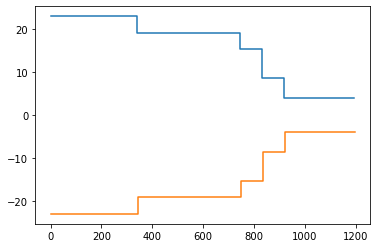

In [44]:
plt.plot(dfOneVL['x'],dfOneVL['Q']
         ,dfOneRL['x'],dfOneRL['Q'])

(2.5, 5.5)

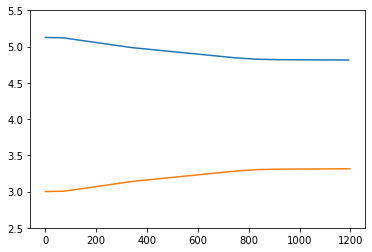

In [45]:
plt.plot(dfOneVL['x'],dfOneVL['P']
         ,dfOneRL['x'],dfOneRL['P'])
plt.ylim((2.5, 5.5))   

(2.5, 5.5)

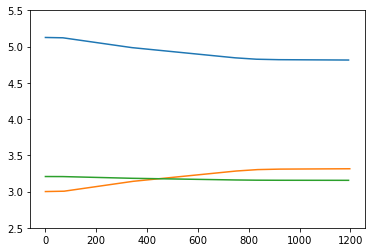

In [46]:
# SIR 3S MIN-Ergebnis lesen
xm.MxAdd(mx=mx,aggReq='TMIN')
vAGSN=xm.dataFrames['vAGSN']
dfOneVLTMIN=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==1)]

plt.plot(dfOneVL['x'],dfOneVL['P']
         ,dfOneRL['x'],dfOneRL['P']
         ,dfOneVL['x'],dfOneVLTMIN['P']         
        )
plt.ylim((2.5, 5.5))   

## Store in H5

In [47]:
xm.ToH5()
mx.ToH5()
# next read will be faster because H5 is read instead of XML / MX if H5 is newer than XML / MX

In [48]:
xm=Xm.Xm(xmlFile=xmlFile)

In [49]:
mx=Mx.Mx(mx1File=mx1File)

In [50]:
#xm?

In [51]:
#mx?

# Rm Plot Beispiele

In [52]:
rm=Rm.Rm(xm=xm,mx=mx)

## Bsp1: Prozentdarstellung - keine Klassen

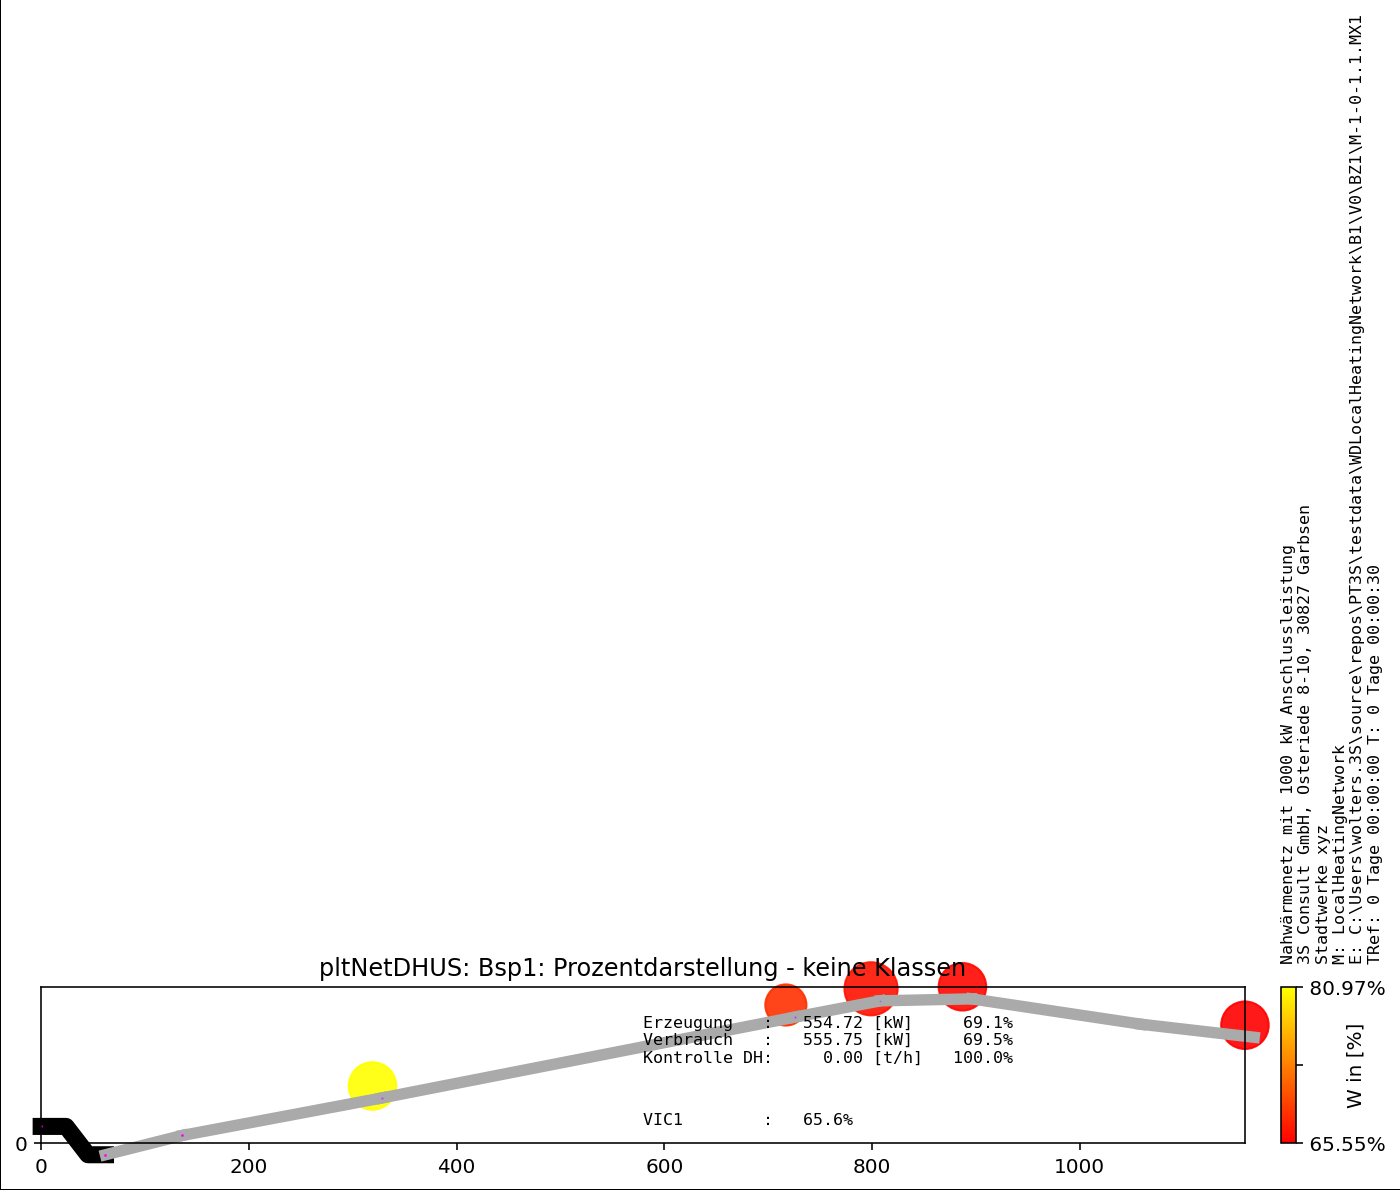

In [53]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                                  
                 pltTitle='pltNetDHUS: Bsp1: Prozentdarstellung - keine Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
    
                 ,pVICsDf=pd.DataFrame({'Kundenname': ['VIC1'],'Knotenname': ['V-K007']})
    
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                     
                   )
plt.show()

## Bsp2: Prozentdarstellung - Klassen

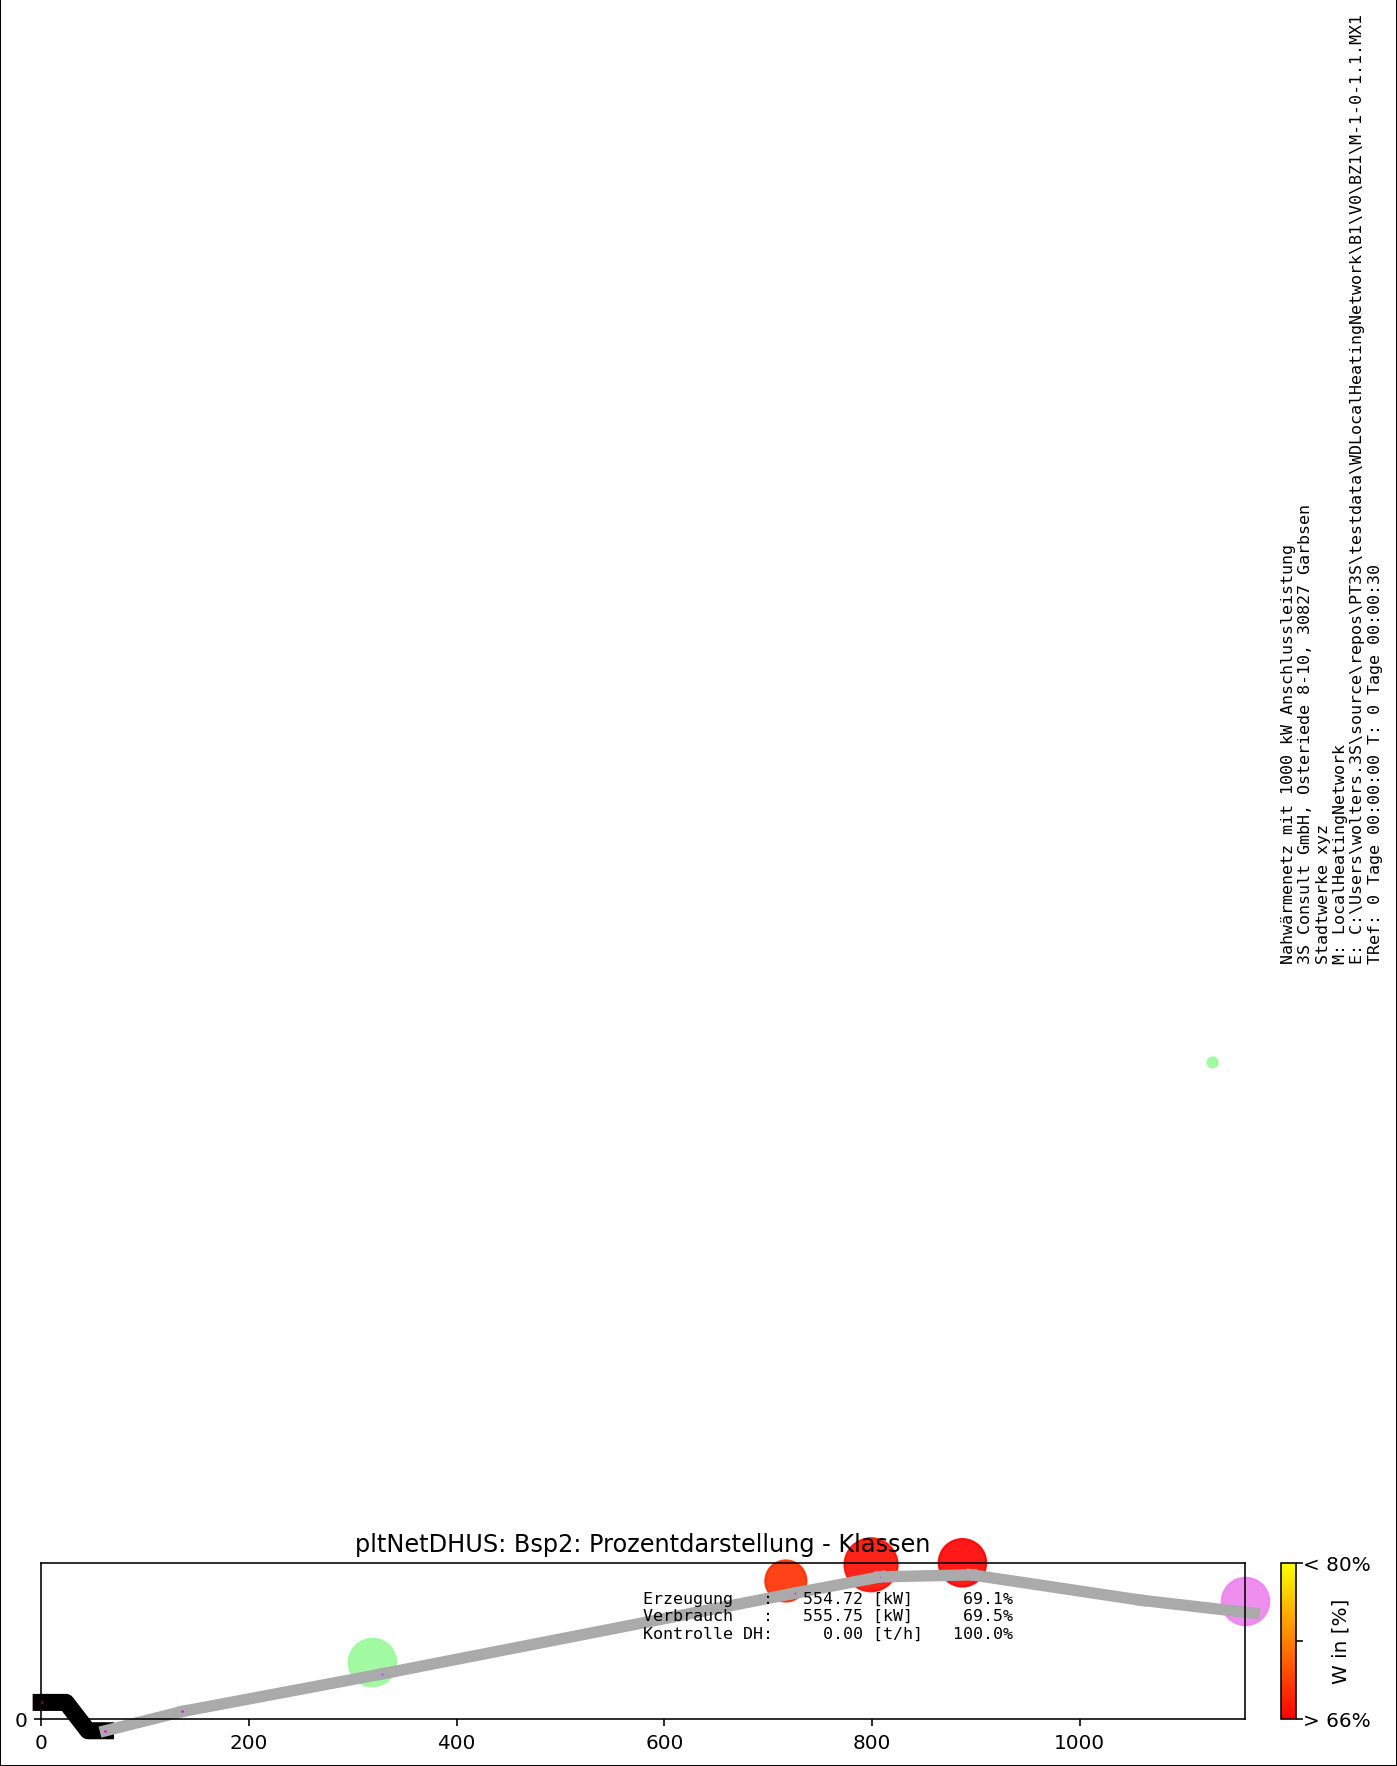

In [54]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                   
                 pltTitle='pltNetDHUS: Bsp2: Prozentdarstellung - Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
    
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureCBFixedLimitHigh=0.80
                 ,pFWVBMeasureCBFixedLimitLow=0.66
                   )
plt.show()

## Bsp3: keine Prozentdarstellung - Klassen

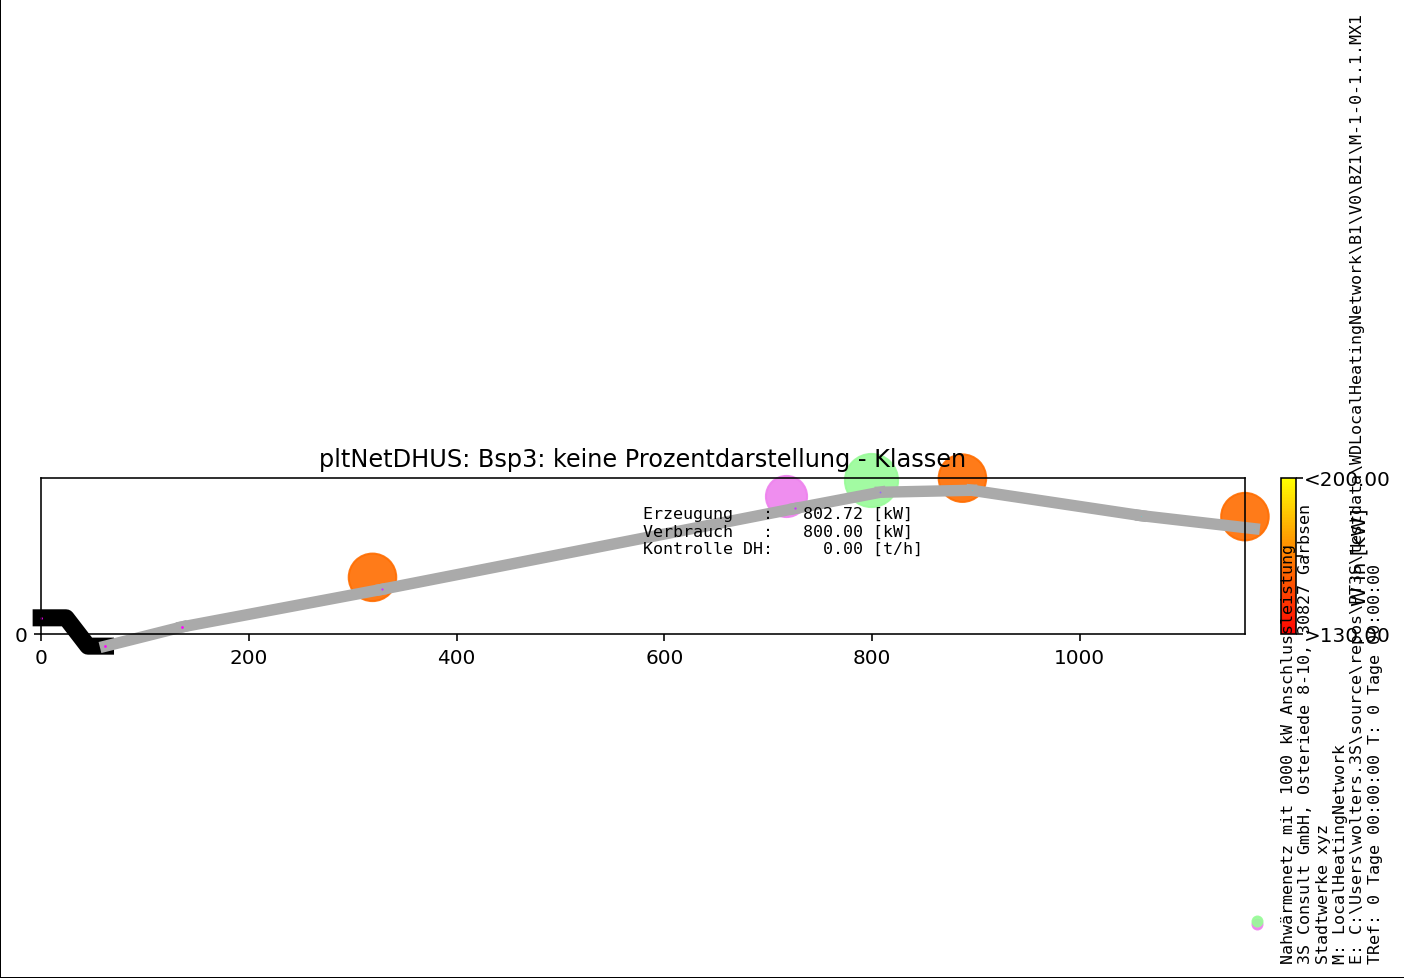

In [55]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(         
                 pltTitle='pltNetDHUS: Bsp3: keine Prozentdarstellung - Klassen'                   
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureInRefPerc=False  
                 ,pFWVBMeasure='FWVB~*~*~*~W' 
                 
                 ,pFWVBMeasureCBFixedLimitHigh=200.
                 ,pFWVBMeasureCBFixedLimitLow=130.
                   )
plt.show()

# NetworkX Beispiele

## hydraulisches Prozessmodell

In [56]:
G=nx.from_pandas_edgelist(xm.dataFrames['vVBEL'], source='NAME_i', target='NAME_k', edge_attr=True,create_using=nx.MultiGraph())

In [57]:
for e, datadict in G.edges.items():
    print(e)
    print(datadict)

('R3', 'V-1', 0)
{'BESCHREIBUNG': 'BHKW - Modul - 1000 kW therm.', 'IDREFERENZ': '-1', 'tk': '5638756766880678918', 'NAME_i': 'R3', 'CONT_i': 'BHKW', 'CONT_VKNO_i': nan, 'Z_i': '20', 'pk_i': '5219230031772497417', 'NAME_k': 'V-1', 'CONT_k': 'BHKW', 'CONT_VKNO_k': nan, 'Z_k': '20', 'pk_k': '5049461676240771430', 'LAYR': ['Vorlauf'], 'L': 0, 'D': '80', 'mx2Idx': 0, 'KNOT~*~*~*~P_i': 3.234365463256836, 'KNOT~*~*~*~HMAX_INST_i': 4.291590690612793, 'KNOT~*~*~*~H_i': 2.234365463256836, 'KNOT~*~*~*~T_i': 60.0, 'KNOT~*~*~*~PDAMPF_i': 0.19919998943805695, 'KNOT~*~*~*~HMIN_INST_i': 2.234365463256836, 'KNOT~*~*~*~PMIN_INST_i': 3.234365463256836, 'KNOT~*~*~*~RHO_i': 983.7000122070312, 'KNOT~*~*~*~PMAX_INST_i': 5.291590690612793, 'KNOT~*~*~*~WALTER_i': 0.49676936864852905, 'KNOT~*~*~*~PH_i': 2.234365463256836, 'KNOT~*~*~*~IAKTIV_i': 0.0, 'KNOT~*~*~*~P_k': 3.207463264465332, 'KNOT~*~*~*~HMAX_INST_k': 4.126019477844238, 'KNOT~*~*~*~H_k': 2.207463264465332, 'KNOT~*~*~*~T_k': 90.0, 'KNOT~*~*~*~PDAMPF_k

In [58]:
for n, nbrsdict in G.adj.items():
    print("!{0:s}".format(n))
    for nox, mgdct in nbrsdict.items(): 
        print("   {0:s}".format(nox))
        for mg,edct in  mgdct.items():
            print("        {0:d}: {1:s}".format(mg,str(edct))) 

!R3
   V-1
        0: {'BESCHREIBUNG': 'BHKW - Modul - 1000 kW therm.', 'IDREFERENZ': '-1', 'tk': '5638756766880678918', 'NAME_i': 'R3', 'CONT_i': 'BHKW', 'CONT_VKNO_i': nan, 'Z_i': '20', 'pk_i': '5219230031772497417', 'NAME_k': 'V-1', 'CONT_k': 'BHKW', 'CONT_VKNO_k': nan, 'Z_k': '20', 'pk_k': '5049461676240771430', 'LAYR': ['Vorlauf'], 'L': 0, 'D': '80', 'mx2Idx': 0, 'KNOT~*~*~*~P_i': 3.234365463256836, 'KNOT~*~*~*~HMAX_INST_i': 4.291590690612793, 'KNOT~*~*~*~H_i': 2.234365463256836, 'KNOT~*~*~*~T_i': 60.0, 'KNOT~*~*~*~PDAMPF_i': 0.19919998943805695, 'KNOT~*~*~*~HMIN_INST_i': 2.234365463256836, 'KNOT~*~*~*~PMIN_INST_i': 3.234365463256836, 'KNOT~*~*~*~RHO_i': 983.7000122070312, 'KNOT~*~*~*~PMAX_INST_i': 5.291590690612793, 'KNOT~*~*~*~WALTER_i': 0.49676936864852905, 'KNOT~*~*~*~PH_i': 2.234365463256836, 'KNOT~*~*~*~IAKTIV_i': 0.0, 'KNOT~*~*~*~P_k': 3.207463264465332, 'KNOT~*~*~*~HMAX_INST_k': 4.126019477844238, 'KNOT~*~*~*~H_k': 2.207463264465332, 'KNOT~*~*~*~T_k': 90.0, 'KNOT~*~*~*~PDA

In [59]:
print(nx.dijkstra_path(G, 'V-L', 'R-L'))

['V-L', 'V-1', 'R3', 'R-1', 'R-L']


In [60]:
max([d for n,d in nx.degree(G)]) 

4

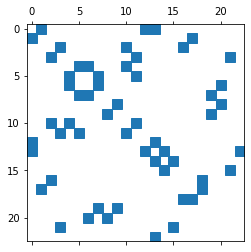

In [61]:
spmtx=nx.adjacency_matrix(G) # Return type: SciPy sparse matrix
plt.spy(spmtx)

Die Laplace-Matrix ist definiert als  L:=D-A, wobei  D die Gradmatrix und  A die Adjazenzmatrix des Graphen bezeichnet.

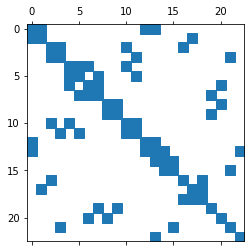

In [62]:
spmtx=nx.laplacian_matrix(G)
plt.spy(spmtx)

In [63]:
nl=[n for n in G.nodes()]

In [64]:
A=nx.to_scipy_sparse_matrix(G)

In [65]:
nlo=scipy.sparse.csgraph.reverse_cuthill_mckee(A)

In [66]:
optnl=[nl[idx] for idx in nlo]

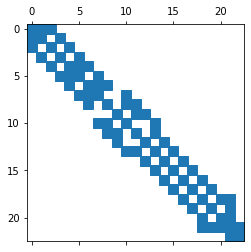

In [67]:
spmtx=nx.laplacian_matrix(G,nodelist=optnl)
plt.spy(spmtx)

### Clean Up

In [68]:
xm.delFiles()
mx.delFiles()

## regelungstechnisches Signalmodell

In [69]:
xmlFile=os.path.join(path,'testdata\DHNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)
mx=xm.MxAdd()

In [70]:
vRSTN=xm.dataFrames['vRSTN']

In [71]:
rstnDiePGRPStellen=vRSTN[[
         'CONT'
        #,'CONT_PARENT'
        ,'KA'
        ,'BESCHREIBUNG'            
        ,'ITYP_OBJTYPE'
        ,'ITYP_OBJATTR'    
        ,'Chk'
        ,'ik_Chk'
      #  ,'OBJTYPE'
        ,'NAME_i'
        ,'NAME_k'     
        ,'CONT_i'  
      #  ,'TABL_Chk'      
      #  ,'TABL'
      #  ,'KNOT'
      #  ,'RART'
      #  ,'RART_TYP'
        ,'RARTPG'
      #  ,'RCPL' 
      #  ,'RCPL_KNOT1'
      #  ,'RCPL_KNOT2'
      #  ,'NAME_i_PUMP'
      #  ,'NAME_k_PUMP'       
        ]].sort_values(by=['ITYP_OBJTYPE','ITYP_OBJATTR','CONT','KA'])[vRSTN['ITYP_OBJTYPE']=='PGRP']
rstnDiePGRPStellen

c:\program files (x86)\microsoft visual studio\shared\python37_64\lib\site-packages\ipykernel_launcher.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


,CONT,KA,BESCHREIBUNG,ITYP_OBJTYPE,ITYP_OBJATTR,Chk,ik_Chk,NAME_i,NAME_k,CONT_i,RARTPG
2,A,KA-0045,NaN,PGRP,AKTIV,1,1.0,R-A-SS,R-A-DS-2,A,NaN
6,B,KA-0057,NaN,PGRP,AKTIV,1,1.0,R-B-SS,R-B-DS-2,B,NaN
10,C,KA-0060,NaN,PGRP,AKTIV,1,1.0,R-C-SS,R-C-DS-2,C,NaN
1,A,KA-0044,NaN,PGRP,DEAKT,1,1.0,R-A-SS,R-A-DS-2,A,NaN
5,B,KA-0053,NaN,PGRP,DEAKT,1,1.0,R-B-SS,R-B-DS-2,B,NaN
9,C,KA-0059,NaN,PGRP,DEAKT,1,1.0,R-C-SS,R-C-DS-2,C,NaN
48,Diverse Steuerungen,KA-0050,Test ohne Fkt.,PGRP,PUDEA,1,1.0,R-A-SS,R-A-DS-2,A,NaN
47,Diverse Steuerungen,KA-0049,Test ohne Fkt.,PGRP,RART,1,1.0,R-A-SS,R-A-DS-2,A,A_dpdS


In [72]:
rstnDiePGRPStellen[rstnDiePGRPStellen['NAME_i']=='R-A-SS']

,CONT,KA,BESCHREIBUNG,ITYP_OBJTYPE,ITYP_OBJATTR,Chk,ik_Chk,NAME_i,NAME_k,CONT_i,RARTPG
2,A,KA-0045,NaN,PGRP,AKTIV,1,1.0,R-A-SS,R-A-DS-2,A,NaN
1,A,KA-0044,NaN,PGRP,DEAKT,1,1.0,R-A-SS,R-A-DS-2,A,NaN
48,Diverse Steuerungen,KA-0050,Test ohne Fkt.,PGRP,PUDEA,1,1.0,R-A-SS,R-A-DS-2,A,NaN
47,Diverse Steuerungen,KA-0049,Test ohne Fkt.,PGRP,RART,1,1.0,R-A-SS,R-A-DS-2,A,A_dpdS


In [73]:
# Verbindungslinien
vREdges=xm.dataFrames['vREdges']

In [74]:
# Signalweg (mit Knotentyp_INFO)
G=nx.from_pandas_edgelist(vREdges, source='KnExt_Ki', target='KnExt_Kk', edge_attr=True,create_using=nx.DiGraph())
nx.shortest_path(G,'Leck_1_Ein_RSLW','KA-0008_RSTN')

['Leck_1_Ein_RSLW',
 'Leck_1_Ein_RUES',
 'Leck_1_VL_RLVG',
 'nLeck_1_VL_RLVG',
 'KA-0008_RSTN']

In [75]:
# Signalweg (ohne Knotentyp)
G=nx.from_pandas_edgelist(vREdges, source='Kn_Ki', target='Kn_Kk', edge_attr=True,create_using=nx.DiGraph())
nx.shortest_path(G,'Leck_1_Ein','KA-0008')

['Leck_1_Ein', 'Leck_1_VL', 'nLeck_1_VL', 'KA-0008']

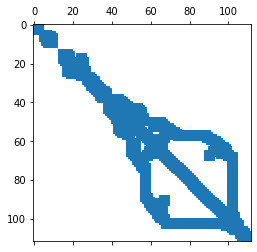

In [76]:
G=nx.from_pandas_edgelist(vREdges, source='Kn_Ki', target='Kn_Kk', edge_attr=True,create_using=nx.Graph())
nl=[n for n in G.nodes()]
A=nx.to_scipy_sparse_matrix(G)
nlo=scipy.sparse.csgraph.reverse_cuthill_mckee(A)
optnl=[nl[idx] for idx in nlo]
spmtx=nx.laplacian_matrix(G,nodelist=optnl)
plt.spy(spmtx)

# Dashboard Beispiele

In [77]:
import pandas as pd
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib import colors
from matplotlib.colorbar import make_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import scipy
import networkx as nx
import re
from itertools import chain
import math
import sys

In [78]:
path='.'
xmlFile=os.path.join(path,'testdata\DHNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)

In [79]:
mx=xm.MxAdd()

In [80]:
xm.ToH5()
mx.ToH5()

## TimeCurve Data

### verfügbare Szenariumzeit

In [81]:
tStartSz=mx.df.index[0]
tEndeSz=mx.df.index[-1]
tStartSz

Timestamp('2018-04-16 00:00:00+0000', tz='UTC')

In [82]:
tEndeSz

Timestamp('2018-04-16 01:00:00+0000', tz='UTC')

In [83]:
timeSpanSz=tEndeSz-tStartSz
timeSpanSz

Timedelta('0 days 01:00:00')

### ausgewählter Zeitbereich

In [84]:
tStart=tStartSz
tEnde=tEndeSz

In [85]:
tcData=mx.df.loc[tStart:tEnde,:]

In [86]:
tcData.index[0]

Timestamp('2018-04-16 00:00:00+0000', tz='UTC')

In [87]:
tcData.index[-1]

Timestamp('2018-04-16 01:00:00+0000', tz='UTC')

### Fwes W

In [88]:
mx1DfFwesW=tcData.filter(regex='^FWES').filter(regex='W$')
mx1DfFwesW=mx1DfFwesW.reindex(sorted(mx1DfFwesW.columns),axis=1)

In [89]:
mx1DfFwesW.head()

,FWES~R-A-DS-2~V-HKW1F~5237816858835684263~W,FWES~R-B-DS-2~V-HKWD~5175187672733343279~W,FWES~R-C-DS-2~V-HWSD~5293515137993465270~W
2018-04-16 00:00:00+00:00,312907.90625,164402.093750,26979.326172
2018-04-16 00:00:00.500000+00:00,312906.37500,164400.187500,26979.353516
2018-04-16 00:00:01+00:00,312905.31250,164398.750000,26979.294922
2018-04-16 00:00:01.500000+00:00,312904.28125,164400.937500,26979.166016
2018-04-16 00:00:02+00:00,312903.40625,164402.140625,26978.955078


<Figure size 417.6x295.2 with 0 Axes>

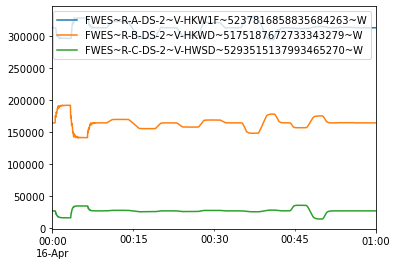

In [90]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfFwesW.plot()

In [91]:
timeSumMaxMx1DfFwesW=mx1DfFwesW.sum(axis=1).idxmax()
timeSumMaxMx1DfFwesW

Timestamp('2018-04-16 00:11:09+0000', tz='UTC')

In [92]:
timeSumMinMx1DfFwesW=mx1DfFwesW.sum(axis=1).idxmin()
timeSumMinMx1DfFwesW

Timestamp('2018-04-16 00:16:07.500000+0000', tz='UTC')

### Pump Q

In [93]:
mx1DfPumpQ=tcData.filter(regex='^PUMP').filter(regex='QM$')
mx1DfPumpQ=mx1DfPumpQ.reindex(sorted(mx1DfPumpQ.columns),axis=1)
mx1DfPumpQ.head()

,PUMP~R-A-SS~R-A-DS~5040653781471340703~QM,PUMP~R-B-SS~R-B-DS~4619979088006137294~QM,PUMP~R-C-SS~R-C-DS~5400942270878162150~QM
2018-04-16 00:00:00+00:00,3538.581543,1852.172363,304.315277
2018-04-16 00:00:00.500000+00:00,3538.564209,1852.150757,304.315582
2018-04-16 00:00:01+00:00,3538.552002,1852.134644,304.314911
2018-04-16 00:00:01.500000+00:00,3538.540283,1852.159302,304.313477
2018-04-16 00:00:02+00:00,3538.530273,1852.172729,304.311096


<Figure size 417.6x295.2 with 0 Axes>

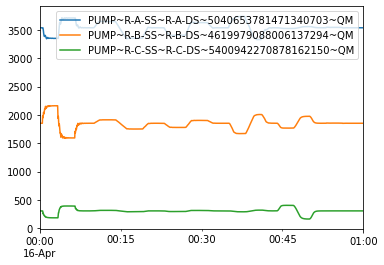

In [94]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfPumpQ.plot()

### Pump Ny

In [95]:
mx1DfPumpNy=tcData.filter(regex='^PUMP').filter(regex='N$')
mx1DfPumpNy=mx1DfPumpNy.reindex(sorted(mx1DfPumpNy.columns),axis=1)

In [96]:
mx1DfPumpNy.head()

,PUMP~R-A-SS~R-A-DS~5040653781471340703~N,PUMP~R-B-SS~R-B-DS~4619979088006137294~N,PUMP~R-C-SS~R-C-DS~5400942270878162150~N
2018-04-16 00:00:00+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:00.500000+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:01+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:01.500000+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:02+00:00,1475.0,1373.0,1387.0


### Pump Nw

In [97]:
mx1DfPumpWCols=[col for col in mx.df.columns.tolist() 
if 
re.match(Mx.reSir3sIDcompiled,col).group('NAME1') in ['wNA','wNB','wNC']
and 
re.match(Mx.reSir3sIDcompiled,col).group('ATTRTYPE') in ['XA']
and 
re.match(Mx.reSir3sIDcompiled,col).group('OBJTYPE') in ['RSLW']
]

In [98]:
mx1DfPumpNw=tcData.filter(items=mx1DfPumpWCols)
mx1DfPumpNw=mx1DfPumpNw.reindex(sorted(mx1DfPumpNw.columns),axis=1)

In [99]:
mx1DfPumpNw.head()

,RSLW~wNA~~4991855568438544033~XA,RSLW~wNB~~4658075570394029953~XA,RSLW~wNC~~5240575308071562858~XA
2018-04-16 00:00:00+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:00.500000+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:01+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:01.500000+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:02+00:00,1475.0,1373.0,1387.0


### Pump Nyw-Pairs

In [100]:
mx1DfPumpNywPairs=pd.concat([mx1DfPumpNy,mx1DfPumpNw],axis=1) 

In [101]:
mx1DfPumpNywPairs=mx1DfPumpNywPairs.filter(items=list(chain.from_iterable(
    [x for x in zip(mx1DfPumpNy.columns.tolist(),mx1DfPumpNw.columns.tolist())]
                                                                         )
                                                     )
                                          ) 

In [102]:
mx1DfPumpNywPairs.head()

,PUMP~R-A-SS~R-A-DS~5040653781471340703~N,RSLW~wNA~~4991855568438544033~XA,PUMP~R-B-SS~R-B-DS~4619979088006137294~N,RSLW~wNB~~4658075570394029953~XA,PUMP~R-C-SS~R-C-DS~5400942270878162150~N,RSLW~wNC~~5240575308071562858~XA
2018-04-16 00:00:00+00:00,1475.0,1475.0,1373.0,1373.0,1387.0,1387.0
2018-04-16 00:00:00.500000+00:00,1475.0,1475.0,1373.0,1373.0,1387.0,1387.0
2018-04-16 00:00:01+00:00,1475.0,1475.0,1373.0,1373.0,1387.0,1387.0
2018-04-16 00:00:01.500000+00:00,1475.0,1475.0,1373.0,1373.0,1387.0,1387.0
2018-04-16 00:00:02+00:00,1475.0,1475.0,1373.0,1373.0,1387.0,1387.0


<Figure size 417.6x295.2 with 0 Axes>

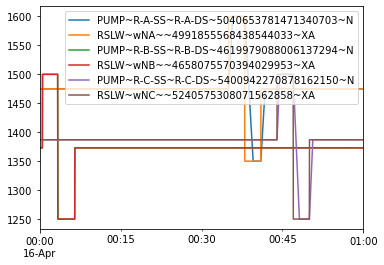

In [103]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfPumpNywPairs.plot()

### Leckagen

In [104]:
mx1DfPipeLIO=tcData.filter(regex='^ROHR').filter(regex='LECKEINAUS$')
mx1DfPipeLIO=mx1DfPipeLIO.reindex(sorted(mx1DfPipeLIO.columns),axis=1)
mx1DfPipeLIO.head()

,ROHR~R-1110~R-1111~4705870204270598692~LECKEINAUS,ROHR~R-1905~R-1906~5311481409516587480~LECKEINAUS,ROHR~R-3008~R-3007~5158013150991786892~LECKEINAUS,ROHR~V-1110~V-1111~5213993202286076270~LECKEINAUS,ROHR~V-1905~V-1906~5678479042185086221~LECKEINAUS,ROHR~V-3008~V-3007~5495210784952840476~LECKEINAUS
2018-04-16 00:00:00+00:00,0,0,0,0,0,1
2018-04-16 00:00:00.500000+00:00,0,0,0,0,0,1
2018-04-16 00:00:01+00:00,0,0,0,0,0,1
2018-04-16 00:00:01.500000+00:00,0,0,0,0,0,1
2018-04-16 00:00:02+00:00,0,0,0,0,0,1


In [105]:
mx1DfPipeLQ=tcData.filter(regex='^ROHR').filter(regex='LECKMENGE$')
mx1DfPipeLQ=mx1DfPipeLQ.reindex(sorted(mx1DfPipeLQ.columns),axis=1)
mx1DfPipeLQ.head()

,ROHR~R-1110~R-1111~4705870204270598692~LECKMENGE,ROHR~R-1905~R-1906~5311481409516587480~LECKMENGE,ROHR~R-3008~R-3007~5158013150991786892~LECKMENGE,ROHR~V-1110~V-1111~5213993202286076270~LECKMENGE,ROHR~V-1905~V-1906~5678479042185086221~LECKMENGE,ROHR~V-3008~V-3007~5495210784952840476~LECKMENGE
2018-04-16 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-16 00:00:00.500000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-16 00:00:01+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-16 00:00:01.500000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-16 00:00:02+00:00,0.0,0.0,0.0,0.0,0.0,0.0


In [106]:
mx1DfPipeLPairs=pd.concat([mx1DfPipeLIO,mx1DfPipeLQ],axis=1) 
mx1DfPipeLPairs=mx1DfPipeLPairs.filter(items=list(chain.from_iterable(
    [x for x in zip(mx1DfPipeLIO.columns.tolist(),mx1DfPipeLQ.columns.tolist())]
                                                                         )
                                                     )
                                          ) 

In [107]:
mx1DfPipeLPairs.describe()

,ROHR~R-1110~R-1111~4705870204270598692~LECKEINAUS,ROHR~R-1110~R-1111~4705870204270598692~LECKMENGE,ROHR~R-1905~R-1906~5311481409516587480~LECKEINAUS,ROHR~R-1905~R-1906~5311481409516587480~LECKMENGE,ROHR~R-3008~R-3007~5158013150991786892~LECKEINAUS,ROHR~R-3008~R-3007~5158013150991786892~LECKMENGE,ROHR~V-1110~V-1111~5213993202286076270~LECKEINAUS,ROHR~V-1110~V-1111~5213993202286076270~LECKMENGE,ROHR~V-1905~V-1906~5678479042185086221~LECKEINAUS,ROHR~V-1905~V-1906~5678479042185086221~LECKMENGE,ROHR~V-3008~V-3007~5495210784952840476~LECKEINAUS,ROHR~V-3008~V-3007~5495210784952840476~LECKMENGE
count,7201.0,7201.000000,7201.0,7201.000000,7201.0,7201.000000,7201.0,7201.000000,7201.0,7201.000000,7201.0,7201.000000
mean,0.0,0.499931,0.0,0.499931,0.0,0.499931,0.0,0.499931,0.0,0.499931,1.0,0.499931
std,0.0,2.179457,0.0,2.179457,0.0,2.179457,0.0,2.179457,0.0,2.179457,0.0,2.179457
min,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,1.0,0.000000
25%,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,1.0,0.000000
50%,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,1.0,0.000000
75%,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,1.0,0.000000
max,0.0,10.000000,0.0,10.000000,0.0,10.000000,0.0,10.000000,0.0,10.000000,1.0,10.000000


In [108]:
# effektive Leckmengen als ~LEAK = ~LECKEINAUS * ~LECKMENGE
colList=mx1DfPipeLPairs.columns.tolist()
for idx in range(0,len(colList),2):

    col=colList[idx]
    mo=re.match(Mx.reSir3sIDcompiled,col)
    colNew=mo.group('OBJTYPE')
    colNew=colNew+Mx.reSir3sIDSep+str(mo.group('NAME1'))
    colNew=colNew+Mx.reSir3sIDSep+mo.group('NAME2')
    colNew=colNew+Mx.reSir3sIDSep+mo.group('OBJTYPE_PK')
    colNew=colNew+Mx.reSir3sIDSep+'LEAK'
    
    mx1DfPipeLPairs[colNew]=mx1DfPipeLPairs.apply(lambda row: row[idx] * row[idx+1] , axis=1)

In [109]:
mx1DfPipeLeaks=mx1DfPipeLPairs.filter(regex='LEAK$')
mx1DfPipeLeaks.describe()

,ROHR~R-1110~R-1111~4705870204270598692~LEAK,ROHR~R-1905~R-1906~5311481409516587480~LEAK,ROHR~R-3008~R-3007~5158013150991786892~LEAK,ROHR~V-1110~V-1111~5213993202286076270~LEAK,ROHR~V-1905~V-1906~5678479042185086221~LEAK,ROHR~V-3008~V-3007~5495210784952840476~LEAK
count,7201.0,7201.0,7201.0,7201.0,7201.0,7201.000000
mean,0.0,0.0,0.0,0.0,0.0,0.499931
std,0.0,0.0,0.0,0.0,0.0,2.179457
min,0.0,0.0,0.0,0.0,0.0,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.000000
50%,0.0,0.0,0.0,0.0,0.0,0.000000
75%,0.0,0.0,0.0,0.0,0.0,0.000000
max,0.0,0.0,0.0,0.0,0.0,10.000000


In [110]:
s=mx1DfPipeLeaks.max()
s=s[s>0]
s.index.tolist()
mx1DfPipeLeaks=mx1DfPipeLeaks.filter(items=s.index.tolist())
mx1DfPipeLeaks.head()

,ROHR~V-3008~V-3007~5495210784952840476~LEAK
2018-04-16 00:00:00+00:00,0.0
2018-04-16 00:00:00.500000+00:00,0.0
2018-04-16 00:00:01+00:00,0.0
2018-04-16 00:00:01.500000+00:00,0.0
2018-04-16 00:00:02+00:00,0.0


<Figure size 417.6x295.2 with 0 Axes>

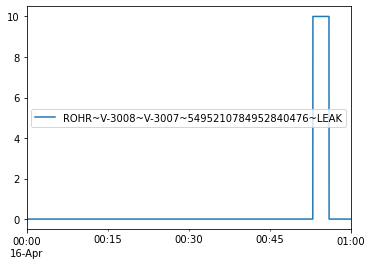

In [111]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfPipeLeaks.plot()

### DH

#### Rename (um die Kanäle ohne die ID auswählen zu können)

In [112]:
colDct={}
for col in tcData.columns.tolist():
    mo=re.match(Mx.reSir3sIDcompiled,col)
    colNew=mo.group('OBJTYPE')
    colNew=colNew+Mx.reSir3sIDSep+str(mo.group('NAME1'))
    colNew=colNew+Mx.reSir3sIDSep+mo.group('NAME2')
    #colNew=colNew+Mx.reSir3sIDSep+mo.group('OBJTYPE_PK')
    colNew=colNew+Mx.reSir3sIDSep+mo.group('ATTRTYPE')
    colDct[col]=colNew
df=tcData.rename(columns=colDct)

In [113]:
mx1DfDH=pd.concat([df['RSLW~wDH_RD_A~~XA']
                  ,df['RMES~yDH_pRL_A~~XA'] 
                  ,df['RSLW~wDH_MD_A~~XA']
                  ,df['RADD~yDH_pMD_A~~XA']                    
                  ]
                  , axis=1)

In [114]:
mx1DfDH.head()

,RSLW~wDH_RD_A~~XA,RMES~yDH_pRL_A~~XA,RSLW~wDH_MD_A~~XA,RADD~yDH_pMD_A~~XA
2018-04-16 00:00:00+00:00,4.2,4.2,6.7,6.650486
2018-04-16 00:00:00.500000+00:00,4.2,4.2,6.7,6.650497
2018-04-16 00:00:01+00:00,4.2,4.2,6.7,6.650503
2018-04-16 00:00:01.500000+00:00,4.2,4.2,6.7,6.650510
2018-04-16 00:00:02+00:00,4.2,4.2,6.7,6.650517


<Figure size 417.6x295.2 with 0 Axes>

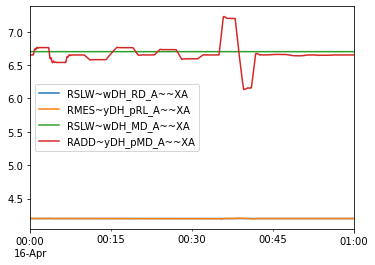

In [115]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfDH.plot()

In [116]:
mx1DfDHQ=pd.concat([df['RMES~QDHGes~~XA'] 
                  ,df['ALLG~~~LINEPACKRATE']                                  
                  ]
                  , axis=1)

In [117]:
mx1DfDHQ.head()

,RMES~QDHGes~~XA,ALLG~~~LINEPACKRATE
2018-04-16 00:00:00+00:00,0.001461,0.000000
2018-04-16 00:00:00.500000+00:00,-0.072597,-0.074034
2018-04-16 00:00:01+00:00,-0.121965,-0.123685
2018-04-16 00:00:01.500000+00:00,-0.157571,-0.159330
2018-04-16 00:00:02+00:00,-0.179570,-0.180519


In [118]:
mx1DfDHV=pd.concat([df['ALLG~~~LINEPACKGEOM']                                  
                  ]
                  , axis=1)
mx1DfDHV=mx1DfDHV-mx1DfDHV['ALLG~~~LINEPACKGEOM'][0]
mx1DfDHV.describe()

,ALLG~~~LINEPACKGEOM
count,7201.000000
mean,0.018437
std,0.223419
min,-0.777344
25%,-0.018555
50%,-0.000977
75%,0.058594
max,0.849609


In [119]:
mx1DfDHV.shape

(7201, 1)

## für Darstellungen, die mit 1 Zeit bzw. mit Aggregaten 1 Zeitraums arbeiten:

Start, Ende, Min, Max

In [120]:
def mxAdd(xm,mx,timeReq=None,aggReq=None,timeReq2nd=None):
    xm.MxAdd(mx=mx,timeReq=timeReq,aggReq=aggReq,timeReq2nd=timeReq2nd)
    vAGSN=xm.dataFrames['vAGSN']
    vKNOT=xm.dataFrames['vKNOT']
    vROHR=xm.dataFrames['vROHR']
    vFWVB=xm.dataFrames['vFWVB']
    vVBEL=xm.dataFrames['vVBEL']
    
    vAGSN=xm.dataFrames['vAGSN']
    vAGSN['PH']=vAGSN.apply(lambda row: row.P*math.pow(10.,5.)/(row.RHO*9.81),axis=1)
    vAGSN['PH']=vAGSN['PH']+vAGSN['Z'].astype('float64')
    zBzg=30.
    vAGSN['bBzg']=vAGSN.apply(lambda row: row.RHO*9.81/math.pow(10.,5.),axis=1)
    vAGSN['zBzg']=           (vAGSN['Z'].astype('float64')-zBzg)*vAGSN['bBzg']
    vAGSN['zBzg0']=          (vAGSN['Z'].astype('float64')-0   )*vAGSN['bBzg']
    vAGSN['zBzgMin']=        (vAGSN['Z'].astype('float64')-vAGSN['Z'].astype('float64').min())*vAGSN['bBzg']
    vAGSN['bBzg']=vAGSN['P']+vAGSN['zBzg']
    
    hpSL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==1)]
    hpRL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==2)]
    
    vROHR=vROHR[(vROHR.apply(lambda x: True if x.CONT_ID == '1001' else False,axis=1))]
    
    return vAGSN,vKNOT,vROHR,vFWVB,vVBEL,hpSL,hpRL

In [121]:
vAGSN_TStart,vKNOT_TStart,vROHR_TStart,vFWVB_TStart,vVBEL_TStart,hpSL_Start,hpRL_Start=mxAdd(xm,mx,timeReq=mx.df.index[0])
vAGSN_TEnde,vKNOT_TEnde,vROHR_TEnde,vFWVB_TEnde,vVBEL_TEnde,hpSL_Ende,hpRL_Ende=mxAdd(xm,mx,timeReq=mx.df.index[-1])
vAGSN_SMin,vKNOT_SMin,vROHR_SMin,vFWVB_SMin,vVBEL_SMin,hpSL_SMin,hpRL_SMin=mxAdd(xm,mx,aggReq='TMIN')
vAGSN_SMax,vKNOT_SMax,vROHR_SMax,vFWVB_SMax,vVBEL_SMax,hpSL_SMax,hpRL_SMax=mxAdd(xm,mx,aggReq='TMAX')

In [122]:
# besserer Weg mehrere Zeiten auf 1x zu erhalten:
xm.MxAdd(mx=mx
,aggReq=['TIME','TMIN','TMAX','TIME'] # Start, Min, Max, Ende # z.B. P	P_1	P_2	P_3
,timeReq=3*[mx.df.index[0]]+[mx.df.index[-1]]
,timeReq2nd=4*[mx.df.index[-1]]
,viewList=['vAGSN','vKNOT','vROHR','vFWVB','vVBEL']
,ForceNoH5Update=True) 

In [123]:
vAGSN=xm.dataFrames['vAGSN']
vAGSN.filter(items=['P','P_1','P_2','P_3'],axis=1).head()

,P,P_1,P_2,P_3
0,10.3034,9.2685,11.4537,10.3034
1,10.3196,9.28493,11.4699,10.3197
2,10.3196,9.28493,11.4699,10.3197
3,10.3102,9.27616,11.46,10.3102
4,10.3102,9.27616,11.46,10.3102


## Farben für Längsschnitte

In [124]:
# bar
hpCSL='red'
hpCRL='blue'
# bBzg
hpCSL2='lightcoral'
hpCRL2='cornflowerblue'
hpZ='black'
# Q
hpCSL3='salmon'
hpCRL3='lightsteelblue'
# bar Min/Max
hpCSLMax='mediumvioletred'
hpCSLMin='palevioletred'
hpCRLMax='darkcyan'
hpCRLMin='aqua'

## Farben für Zeitkurven

### Definitionen

In [125]:
# Linienattribute für Paare von Linien
lwThick=mpl.rcParams['lines.linewidth']*2 # zuerst gezeichnete Linie (hell)
lsThin='--' # danach gezeichnete Linie (dunkel)

### Festlegung der Farben

In [126]:
# fuer A,B,C: Auswahl aus konstruierten Tönen
ntcCat=10
ntcCatSub=3 
tcCm=Rm.pltMakeCategoricalCmap(catagoryColors=[idx for idx in range(ntcCat)],nOfSubCatsReq=ntcCatSub)

catA=0 # blau
catB=1 # orange
catC=2 # grün
catFromIdx={}
catFromIdx[0]=catA
catFromIdx[1]=catB
catFromIdx[2]=catC

# DH: RD,MD,VD: 
tcC_SL=plt.get_cmap("tab20b").colors[3*4+2] 
tcC_RL=plt.get_cmap("tab20b").colors[0*4+2] 
tcC_ML=plt.get_cmap("tab20b").colors[4*4+2] 

tcC_SLl=plt.get_cmap("tab20b").colors[3*4+3] 
tcC_RLl=plt.get_cmap("tab20b").colors[0*4+3] 
tcC_MLl=plt.get_cmap("tab20b").colors[4*4+3]

# DH: RD,MD-Paare: Sequenzen
tcC_XL=[tcC_RLl,tcC_RL,tcC_MLl,tcC_ML]
tcLs_XL=[mpl.rcParams['lines.linestyle'],lsThin,mpl.rcParams['lines.linestyle'],lsThin]
tcLw_XL=[lwThick,mpl.rcParams['lines.linewidth'],lwThick,mpl.rcParams['lines.linewidth']]

# DH: Q,Linepackrate:
tcC_QDH=plt.get_cmap("tab20b").colors[2*4+0] 
tcC_QLPRate=plt.get_cmap("tab20b").colors[2*4+3] 

# DH: Q,Linepackrate-Paar: Sequenz
tcC_DH=[tcC_QDH,tcC_QLPRate]
tcLs_DH=[mpl.rcParams['lines.linestyle'],lsThin]
tcLw_DH=[lwThick,mpl.rcParams['lines.linewidth']]

# DH: V
tcC_VDH=plt.get_cmap("tab20b").colors[1*4+2] 

## Plot

In [127]:
# 2 Zeiten auswählen
time1=timeSumMaxMx1DfFwesW
time2=timeSumMinMx1DfFwesW

In [128]:
# Ergebnisse für die 2 Zeiten holen
vAGSN_T1,vKNOT_T1,vROHR_T1,vFWVB_T1,vVBEL_T1,hpSL_T1,hpRL_T1=mxAdd(xm,mx,timeReq=time1)
vAGSN_T2,vKNOT_T2,vROHR_T2,vFWVB_T2,vVBEL_T2,hpSL_T2,hpRL_T2=mxAdd(xm,mx,timeReq=time2)

In [129]:
# Ref/Cmp zuordnen
timeRef=time1
timeCmp=time2

hpSLRef=hpSL_T1
hpRLRef=hpRL_T1

hpSLCmp=hpSL_T2
hpRLCmp=hpRL_T2

vROHRRef=vROHR_T1
vROHRCmp=vROHR_T2

In [130]:
vROHR_NFD=pd.merge(vROHRRef
         ,hpRLRef[hpRLRef.IptIdx=='S']
         ,how='left'
         ,left_on='pk'
         ,right_on='OBJID'
         ,suffixes=('','_AGSN')).filter(items=vROHRRef.columns.tolist()+['OBJID'])

c:\program files (x86)\microsoft visual studio\shared\python37_64\lib\site-packages\ipykernel_launcher.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


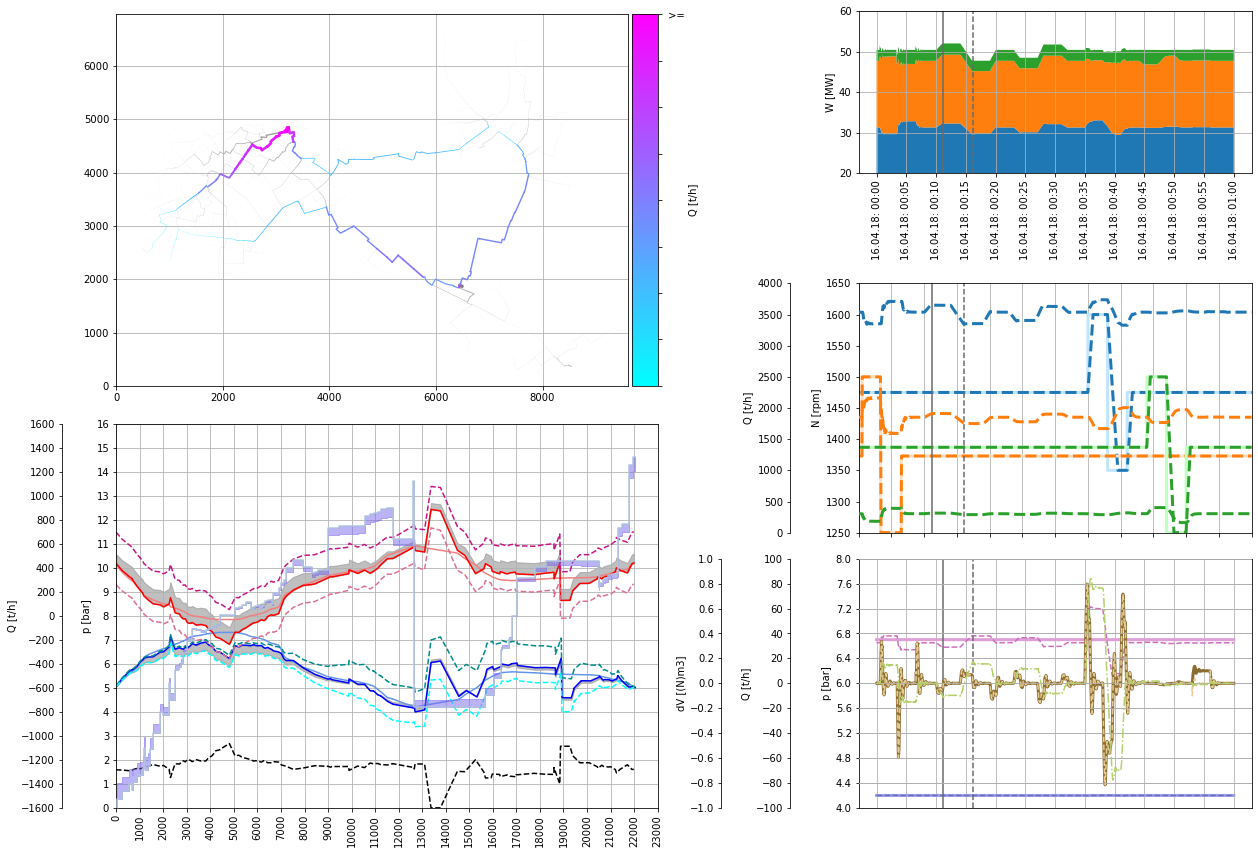

In [131]:
plt.close()

size_DINA3quer=(16.5, 11.7) 
plt.rc('figure',figsize=size_DINA3quer) 
plt.rc('figure',dpi=72)
plt.rc('savefig',dpi=72*2)
fig=plt.figure()

# .............................................................
# Paramtrierung
# .............................................................
# links: 1 NFD und 1 NDD
# .............................................................
# links nimmt die ganz linke Hälfte des Dashboards ein
leftTileRight=0.5

# rechts: 3 ZKs
# .............................................................
# rechts nimmt die ganz linke Hälfte des Dashboards ein 
rightTileStart=1-leftTileRight
# allerdings wird Platz für die y-Achsen benötigt
rightTileYAxisXSpace=0.125
rightTileStart=rightTileStart+rightTileYAxisXSpace
rightTileH_pad=0.5

# x-Achse
#majLocator=mdates.MinuteLocator(interval=5)
majLocator=mdates.MinuteLocator(byminute=[0,5,10,15,20,25,30,35,40,45,50,55])
majFormatter=mdates.DateFormatter('%d.%m.%y: %H:%M')

# .............................................................
# links: 1 NFD und 1 NDD
# .............................................................
gs1 = gridspec.GridSpec(2, 1)
axNfd = fig.add_subplot(gs1[0])
axHp = fig.add_subplot(gs1[1])
gs1.tight_layout(fig, rect=[0, 0, leftTileRight, 1])
    #rect : if rect is given, it is interpreted as a rectangle
    #(left, bottom, right, top) in the normalized figure coordinate that the whole subplots area (including labels) will fit into

# .............................................................
# NFD
# .............................................................
Rm.Rm.pltNetPipes(vROHR_NFD
,query="CONT_ID == '1001'"
,fmask=lambda row: True if row.KVR_i=='2' and row.KVR_k=='2' else False 
,pAx=axNfd
,pAttributeFunc=lambda row: math.fabs(row['ROHR~*~*~*~QMAV'])
,pAttributeColorMapMin=0.
,pAttributeColorMapMax=1600.
,CBLabel='Q [t/h]'    
,sort_values_by=['pAttributeFunc'] 
,sort_values_ascending=True       
,pAttributeColorMapFmask=lambda row: True if not pd.isnull(row.OBJID) else False 
,pAttributeColorMap2ndFmask=lambda row: True if pd.isnull(row.OBJID) else False 
,pAttributeColorMap2ndUsageStart=1./4. # nicht zu weiß 
,pAttributeColorMap2ndUsageEnd=1./2. # nicht zu schwarz
)    
# .............................................................
# HP
# .............................................................
    
# (negativer) Abstand der 2. y-Achse von der Zeichenfläche
yTwinedAxesPosDeltaHP=-0.100

axHp.set_ylabel('p [bar]')  
axHp.set_ylim(0,16)          
axHp.set_yticks(np.arange(0, 16.1, 1))  

axHp.plot(hpSLRef['x'],hpSLRef['bBzg'],color=hpCSL2)        
axHp.plot(hpRLRef['x'],hpRLRef['bBzg'],color=hpCRL2)   

axHp.plot(hpSLRef['x'],hpSLRef['zBzgMin'],color=hpZ,ls='--')   

axHp.plot(hpSLRef['x'],hpSLRef['P'],color=hpCSL)        
axHp.plot(hpRLRef['x'],hpRLRef['P'],color=hpCRL)   


hpSLRef = hpSLRef.apply(pd.to_numeric, errors='ignore')
hpSLCmp = hpSLCmp.apply(pd.to_numeric, errors='ignore')
axHp.fill_between(hpSLRef['x'], hpSLRef['P'], hpSLCmp['P'], color='grey', alpha=0.5)
hpRLRef = hpRLRef.apply(pd.to_numeric, errors='ignore')
hpRLCmp = hpRLCmp.apply(pd.to_numeric, errors='ignore')
axHp.fill_between(hpRLRef['x'], hpRLRef['P'], hpRLCmp['P'], color='grey', alpha=0.5)

axHp.plot(hpSL_SMax['x'],hpSL_SMax['P'],color=hpCSLMax,ls='--')        
axHp.plot(hpSL_SMin['x'],hpSL_SMin['P'],color=hpCSLMin,ls='--')   

axHp.plot(hpRL_SMax['x'],hpRL_SMax['P'],color=hpCRLMax,ls='--')        
axHp.plot(hpRL_SMin['x'],hpRL_SMin['P'],color=hpCRLMin,ls='--') 



# x-Achse
ax=axHp
axHp.set_xlim(0,23000)          
axHp.set_xticks(np.arange(0, 23000.1, 1000))      
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.grid()

# 2. y-Achse
axHp_2nd = axHp.twinx()
axHp_2nd.spines["left"].set_position(("axes", yTwinedAxesPosDeltaHP)) 
Rm.pltMakePatchSpinesInvisible(axHp_2nd)
axHp_2nd.spines['left'].set_visible(True)  
axHp_2nd.yaxis.set_label_position('left')
axHp_2nd.yaxis.set_ticks_position('left')

axHp_2nd.set_ylabel('Q [t/h]')  
axHp_2nd.set_ylim(-1600,1600)          
axHp_2nd.set_yticks(np.arange(-1600, 1600.1, 200))
axHp_2nd.plot(hpRLRef['x'],hpRLRef['Q'],color=hpCRL3,ls='-')        
axHp_2nd.fill_between(hpRLRef['x'], hpRLRef['Q'], hpRLCmp['Q'], color='mediumslateblue', alpha=0.5)



    
    
# .............................................................
# rechts: 3 ZKs
# .............................................................
gs2 = gridspec.GridSpec(3, 1)
axTcUp = fig.add_subplot(gs2[0])
axTcMi = fig.add_subplot(gs2[1])
axTcBo = fig.add_subplot(gs2[2])
gs2.tight_layout(fig, rect=[rightTileStart, 0, 1, 1], h_pad=rightTileH_pad)
    #pad : float
    #padding between the figure edge and the edges of subplots, as a fraction of the font-size
    #h_pad, w_pad : float
    #padding (height/width) between edges of adjacent subplots

# (negativer) Abstand der 2. y-Achse von der Zeichenfläche
yTwinedAxesPosDelta=-0.175

# .............................................................
# oberste ZK
# .............................................................
axTcUp.stackplot(mx1DfFwesW.index.values #x
                 ,np.row_stack([mx1DfFwesW[col].values for col in mx1DfFwesW.columns.tolist()]) #y
                 ,colors=[tcCm.colors[catA*ntcCatSub+0],tcCm.colors[catB*ntcCatSub+0],tcCm.colors[catC*ntcCatSub+0]]
                 ,labels=['A','B','C']
                )
axTcUp.set_ylabel('W [MW]') 
axTcUp.set_ylim(200000,600000)          
axTcUp.set_yticks(np.arange(200000, 600001, 100000))
axTcUp.set_yticklabels(["{0:2.0f}".format(x) for x in np.arange(20, 60.1,10)])
# x-Achse
ax=axTcUp
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.grid()
# wg. der x-Achse (nur in der obersten ZK) muss der eigentliche Zeichenbereich verkleinert werden
pos1 = ax.get_position()
pos2 = [pos1.x0, pos1.y0+0.10,  pos1.width, pos1.height * 0.65] 
ax.set_position(pos2) 

# .............................................................
# mittlere ZK
# .............................................................

# Bsp. Plot mit pltTC
yAxes,yLines,vLines,yLinesLegendLabels=Rm.Rm.pltTC(pd.concat([mx1DfPumpNywPairs,mx1DfPumpQ],axis=1)
            ,tcLines={ 
              'RSLW~wNA~~XA'
                   :{'label':'RSLW~wNA~~XA'  
                     ,'forceYType':'N'
                     ,'color':tcCm.colors[catFromIdx[0]*ntcCatSub+ntcCatSub-1]
                     ,'linestyle':'-'
                     ,'linewidth':lwThick}
              ,'PUMP~R-A-SS~R-A-DS~N'
                   :{'label':'PUMP~R-A-SS~R-A-DS~N','color':tcCm.colors[catFromIdx[0]*ntcCatSub+0]
                     ,'linestyle':lsThin}    
              ,'RSLW~wNB~~XA'
                   :{'label':'RSLW~wNB~~XA'  
                     ,'forceYType':'N'
                     ,'color':tcCm.colors[catFromIdx[1]*ntcCatSub+ntcCatSub-1]
                     ,'linestyle':'-'
                     ,'linewidth':lwThick}
              ,'PUMP~R-B-SS~R-B-DS~N'
                   :{'label':'PUMP~R-B-SS~R-B-DS~N','color':tcCm.colors[catFromIdx[1]*ntcCatSub+0]
                     ,'linestyle':lsThin}    
              ,'RSLW~wNC~~XA'
                   :{'label':'RSLW~wNC~~XA'  
                     ,'forceYType':'N'
                     ,'color':tcCm.colors[catFromIdx[2]*ntcCatSub+ntcCatSub-1]
                     ,'linestyle':'-'
                     ,'linewidth':lwThick}
              ,'PUMP~R-C-SS~R-C-DS~N'
                   :{'label':'PUMP~R-C-SS~R-C-DS~N','color':tcCm.colors[catFromIdx[2]*ntcCatSub+0]
                     ,'linestyle':lsThin}  
            
              ,'PUMP~R-A-SS~R-A-DS~QM'
                   :{'label':'PUMP~R-A-SS~R-A-DS~QM','color':tcCm.colors[catFromIdx[0]*ntcCatSub+0]
                     ,'linestyle':lsThin}    
              ,'PUMP~R-B-SS~R-B-DS~QM'
                   :{'label':'PUMP~R-B-SS~R-B-DS~QM','color':tcCm.colors[catFromIdx[1]*ntcCatSub+0]
                     ,'linestyle':lsThin}    
              ,'PUMP~R-C-SS~R-C-DS~QM'
                   :{'label':'PUMP~R-C-SS~R-C-DS~QM','color':tcCm.colors[catFromIdx[2]*ntcCatSub+0]
                     ,'linestyle':lsThin}                  
                
                
             }
            ,pAx=axTcMi  
            ,majLocator=majLocator
            ,majFormatter=majFormatter
            ,xTicksLabelsOff=True
            ,yTwinedAxesPosDeltaHPStart=0
            ,yTwinedAxesPosDeltaHP=-0.175    
            ,lOff=True
            )

yAxes['N'].set_ylabel('N [rpm]')   
yAxes['N'].set_ylim(1250,1650)          
yAxes['N'].set_yticks(np.arange(1250, 1651, 50))

yAxes['QM'].set_ylabel('Q [t/h]')   
yAxes['QM'].set_ylim(0,4000)          
yAxes['QM'].set_yticks(np.arange(0, 4001, 500))

# .............................................................
# untere ZK
# .............................................................
axTcBo.set_ylabel('p [bar]')   
axTcBo.set_ylim(4,8)          
axTcBo.set_yticks(np.arange(4, 8.1, .4))
for idx,col in enumerate(mx1DfDH.columns.tolist()):
    line,=axTcBo.plot(mx1DfDH.index.values,mx1DfDH[col]                     
                      ,color= tcC_XL[idx]
                      ,ls=tcLs_XL[idx]
                      ,lw=tcLw_XL[idx]
                     )

    
ax=axTcBo
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
ax.set_xticklabels([])
ax.grid()
# x-Achsenbeschriftung ausschalten
for tic in ax.xaxis.get_major_ticks():
    tic.tick1On = tic.tick2On = False

# 2. y-Achse
axTcBo_2nd = axTcBo.twinx()
axTcBo_2nd.spines["left"].set_position(("axes", yTwinedAxesPosDelta)) 
Rm.pltMakePatchSpinesInvisible(axTcBo_2nd)
axTcBo_2nd.spines['left'].set_visible(True)  
axTcBo_2nd.yaxis.set_label_position('left')
axTcBo_2nd.yaxis.set_ticks_position('left')
axTcBo_2nd.set_ylabel('Q [t/h]')   
axTcBo_2nd.set_ylim(-100,100)          
axTcBo_2nd.set_yticks(np.arange(-100, 101, 20))
for idx,col in enumerate(mx1DfDHQ.columns.tolist()):
    line,=axTcBo_2nd.plot(mx1DfDHQ.index.values,mx1DfDHQ[col]                     
                      ,color= tcC_DH[idx]
                      ,ls=tcLs_DH[idx]
                      ,lw=tcLw_DH[idx]
                     )
# x-Achsenbeschriftung ausschalten
ax=axTcBo_2nd
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.set_xticklabels([])
ax.grid()
for tic in ax.xaxis.get_major_ticks():
    tic.tick1On = tic.tick2On = False

# 3. y-Achse
axTcBo_3rd = axTcBo.twinx()
axTcBo_3rd.spines["left"].set_position(("axes", yTwinedAxesPosDelta*2)) 
Rm.pltMakePatchSpinesInvisible(axTcBo_3rd)
axTcBo_3rd.spines['left'].set_visible(True)  
axTcBo_3rd.yaxis.set_label_position('left')
axTcBo_3rd.yaxis.set_ticks_position('left')
axTcBo_3rd.set_ylabel('dV [(N)m3]')  
axTcBo_3rd.set_ylim(-1,1)          
axTcBo_3rd.set_yticks(np.arange(-1, 1.1, .2))
line,=axTcBo_3rd.plot(mx1DfDHV.index.values,mx1DfDHV['ALLG~~~LINEPACKGEOM']                     
                      ,color= tcC_VDH
                      ,ls='-.'            
                     )
# x-Achsenbeschriftung ausschalten
ax=axTcBo_3rd
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.set_xticklabels([])
ax.grid()
for tic in ax.xaxis.get_major_ticks():
    tic.tick1On = tic.tick2On = False


    
# Zeitcursor für 2 Zeiten in allen ZKs darstellen
axLst=[axTcUp,axTcMi,axTcBo]
for ax in axLst:
    vLinePlotted=ax.axvline(x=timeRef, ymin=0, ymax=1
                              ,label='Zeit 1'
                              ,color='dimgrey'
                           #   ,linestyle=linestyle
                           #   ,linewidth=linewidth
                           )     
    vLinePlotted=ax.axvline(x=timeCmp, ymin=0, ymax=1
                              ,label='Zeit 2'
                              ,color='dimgrey'
                              ,linestyle='--'
                           #   ,linewidth=linewidth
                           )    
plt.savefig('Dashboard.pdf',format='pdf',bbox_inches='tight')#,pad_inches=2)

In [132]:
# wieder 1. Zeit
mx=xm.MxAdd()

In [133]:
vROHR=xm.dataFrames['vROHR']
vROHR.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1678 entries, 0 to 1677
Data columns (total 84 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   BESCHREIBUNG       0 non-null      object 
 1   IDREFERENZ         1678 non-null   object 
 2   BAUJAHR            1678 non-null   object 
 3   HAL                1678 non-null   object 
 4   IPLANUNG           1678 non-null   object 
 5   KENNUNG            1678 non-null   object 
 6   L                  1678 non-null   object 
 7   LZU                1678 non-null   object 
 8   RAU                1678 non-null   object 
 9   ZAUS               1678 non-null   object 
 10  ZEIN               1678 non-null   object 
 11  ZUML               1678 non-null   object 
 12  JLAMBS             1678 non-null   object 
 13  LAMBDA0            1678 non-null   object 
 14  ASOLL              1678 non-null   object 
 15  INDSCHALL          1678 non-null   object 
 16  NAME_i_2L          1678 

In [134]:
vKNOT=xm.dataFrames['vKNOT']

In [135]:
vKNOTexp=xm.vKNOTexpEBES()

In [136]:
import re
qsCols=[col for col in vKNOTexp.columns.tolist() if re.search('^qs_',col) != None]
qsCols

['qs_1_A', 'qs_2_B', 'qs_3_C']

In [137]:
qsInfCols=[col for col in vKNOTexp.columns.tolist() if re.search('^qs[a-zA-Z0-9]+',col) != None]
qsInfCols

['qsStr',
 'qsigStr',
 'qs100',
 'qsSUM',
 'qsA',
 'qsNotA',
 'qsARank',
 'qsAnzKnoten',
 'qsAnzFwvb',
 'qsFWVB~*~*~*~W',
 'qsFWVB~*~*~*~QM',
 'qsRank',
 'qsRankAnzKnoten',
 'qsRankAnzFwvb',
 'qsRankFWVB~*~*~*~W',
 'qsigAnzKnoten',
 'qsigAnzFwvb',
 'qsigFWVB~*~*~*~W',
 'qsigFWVB~*~*~*~QM',
 'qsigRank',
 'qsigRankAnzKnoten',
 'qsigRankAnzFwvb',
 'qsigRankFWVB~*~*~*~W',
 'qsigqsRankFWVB~*~*~*~W']

In [138]:
vROHRexp=xm.vROHRexpEBES(vKNOTexp)

In [139]:
vROHRexp.shape

(1678, 116)

In [140]:
vROHR.shape

(1678, 84)

In [141]:
vROHRexp['QAbs']=vROHRexp.apply(lambda row: math.fabs(row['ROHR~*~*~*~QMAV']),axis=1)  

In [142]:
vROHRexp=vROHRexp[vROHRexp['KVR']=='1']

In [143]:
grpObj=vROHRexp.groupby(by=['qsigRank'],as_index=False)        
d={col:'min' for col in ['qsigStr','qs_1_A','qs_2_B','qs_3_C']}       
d.update({'qsigFWVB~*~*~*~W':'min'})      
d.update({'qsigRank_sumL':'min'})   
df=grpObj.agg(d).sort_values(by=['qsigRank'],ascending=True)       
df

,qsigRank,qsigStr,qs_1_A,qs_2_B,qs_3_C,qsigFWVB~*~*~*~W,qsigRank_sumL
0,1,110,6,1,0,184816.274504,51151.5221
1,2,100,100,0,0,182017.147639,36841.2302
2,3,011,0,66,34,2194.113852,259.7644
3,4,010,0,100,0,92498.916278,37422.8914
4,5,001,0,0,100,25189.329991,7278.5539


In [144]:
df[df['qsigStr']=='100']['qsigFWVB~*~*~*~W'].iloc[0]


182017.1476392746

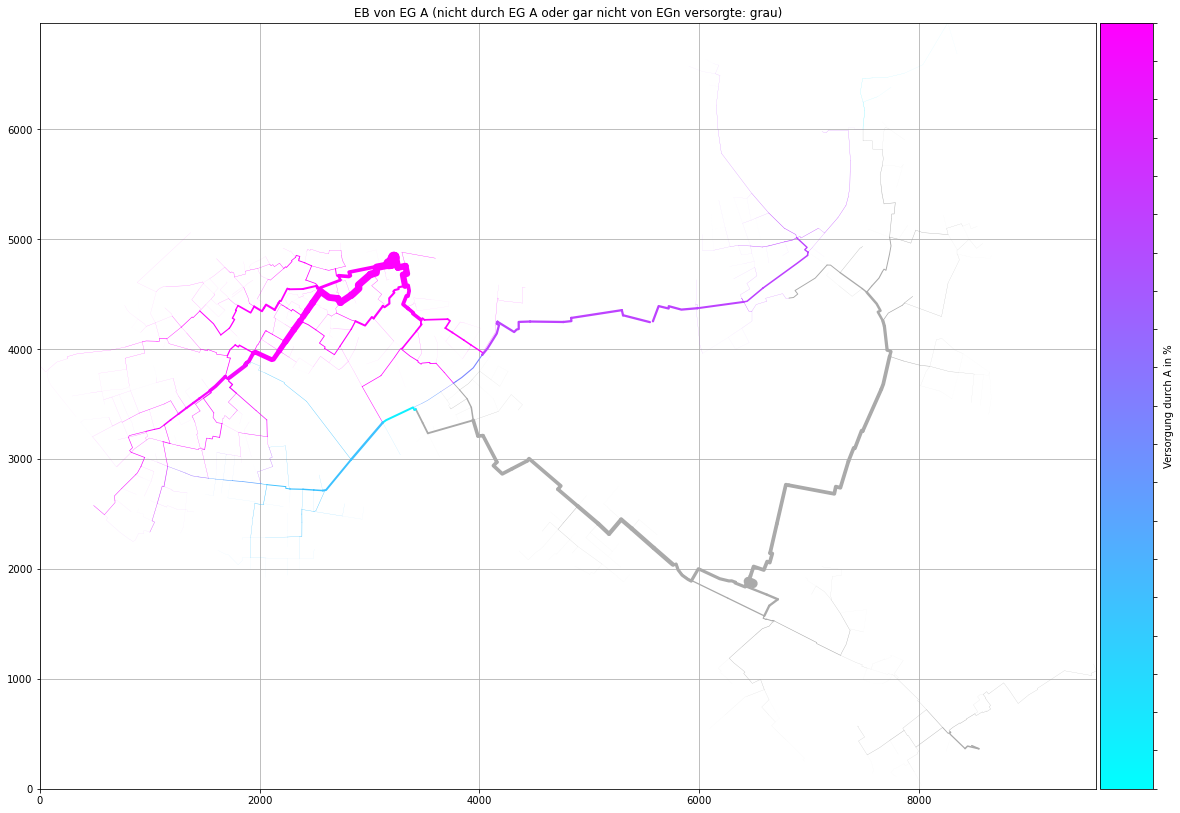

In [145]:

plt.close()
size_DINA3quer=(16.5, 11.7) 
dpiSize=72
fig=plt.figure(figsize=size_DINA3quer,dpi=dpiSize)         
gs = gridspec.GridSpec(1, 1)

# ---
# 
axNfd = fig.add_subplot(gs[0])              
Rm.Rm.pltNetPipes(vROHRexp
    ,query="CONT_ID == '1001'"
    ,fmask=lambda row: True if row.KVR_i=='1' and row.KVR_k=='1' else False 
    ,pAx=axNfd
    ,pAttribute='qsA'
    ,pAttributeColorMapFmask=lambda row: True if row.qsA >0 else False 
    ,pAttributeColorMap2ndFmask=lambda row: True if row.qsA <=0  else False   # da A 0 ist wird nur 1 Farbwert verwendet; 
                  # ... keine Unterscheidung zwischen von A nicht versorgten und gar nicht versorgten                  
    ,pAttrLineSize='QAbs'
    ,sort_values_by=['QAbs'] 
    ,sort_values_ascending=True      
    ,pAttrLineSizeFactor=3*1./(vROHRexp['QAbs'].std()*2.)        
    ,pAttributeColorMap2ndUsageStart=1./3
    ,CBBinTicks=21 
    ,CBLabel='Versorgung durch A in %'
    )    
txt=axNfd.set_title('EB von EG A (nicht durch EG A oder gar nicht von EGn versorgte: grau)')



gs.tight_layout(fig)
plt.show()

In [146]:
# dasselbe mit einer diskreten CM die eine explizite Aussage trifft was magenta und was cyan sein soll
cmap = matplotlib.colors.ListedColormap(np.vstack(
    (
     Rm.pltMakeCategoricalColors(list(matplotlib.colors.to_rgb('cyan')),nOfSubColorsReq=5,reversedOrder=False),
     Rm.pltMakeCategoricalColors(list(matplotlib.colors.to_rgb('magenta')),nOfSubColorsReq=15,reversedOrder=True)
    )
))       

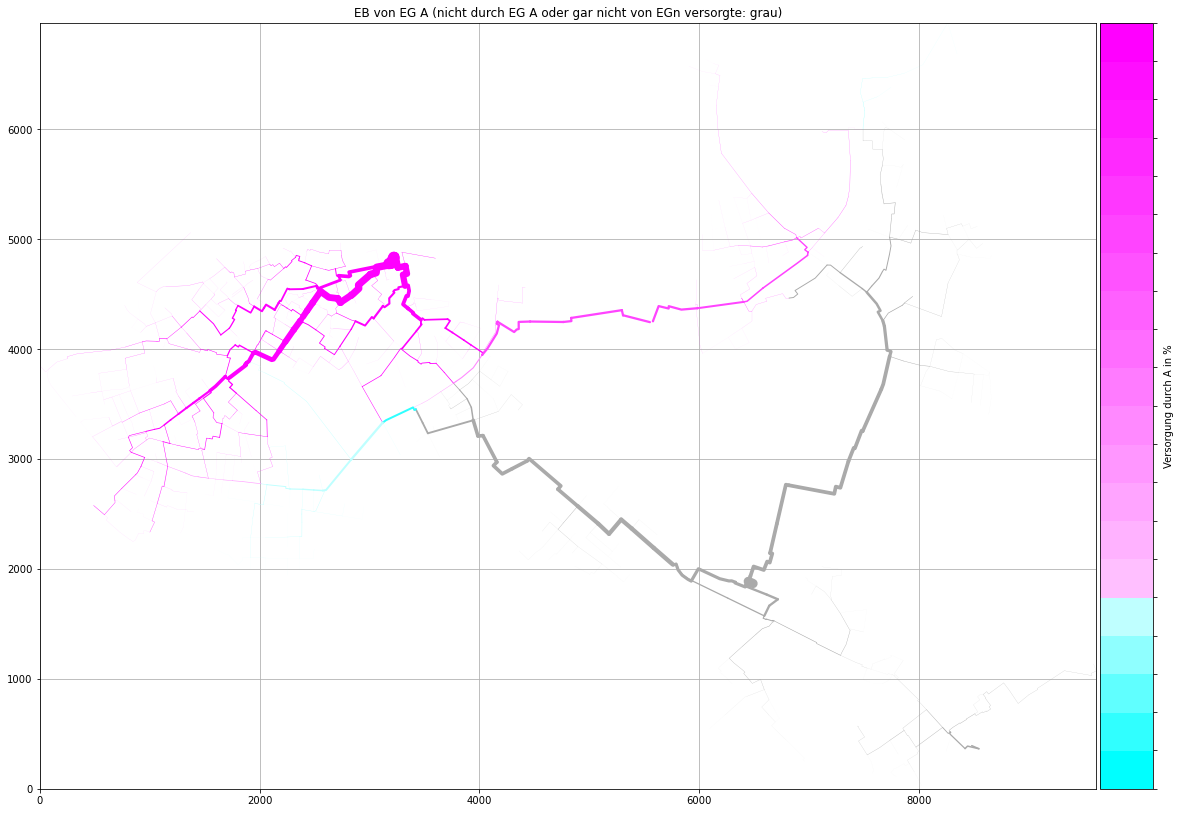

In [147]:
plt.close()
size_DINA3quer=(16.5, 11.7) 
dpiSize=72
fig=plt.figure(figsize=size_DINA3quer,dpi=dpiSize)         
gs = gridspec.GridSpec(1, 1)

# ---
# 
axNfd = fig.add_subplot(gs[0])              
Rm.Rm.pltNetPipes(vROHRexp
    ,query="CONT_ID == '1001'"
    ,fmask=lambda row: True if row.KVR_i=='1' and row.KVR_k=='1' else False 
    ,pAx=axNfd
    ,pAttribute='qsA'
    ,pAttributeColorMap=cmap 
    ,pAttributeColorMapFmask=lambda row: True if row.qsA >0 else False 
    ,pAttributeColorMap2ndFmask=lambda row: True if row.qsA <=0  else False   # da A 0 ist wird nur 1 Farbwert verwendet; 
                  # ... keine Unterscheidung zwischen von A nicht versorgten und gar nicht versorgten                  
    ,pAttrLineSize='QAbs'
    ,sort_values_by=['QAbs'] 
    ,sort_values_ascending=True      
    ,pAttrLineSizeFactor=3*1./(vROHRexp['QAbs'].std()*2.)        
    ,pAttributeColorMap2ndUsageStart=1./3
    ,CBBinTicks=21 
    ,CBLabel='Versorgung durch A in %'
    )    
txt=axNfd.set_title('EB von EG A (nicht durch EG A oder gar nicht von EGn versorgte: grau)')



gs.tight_layout(fig)
plt.show()

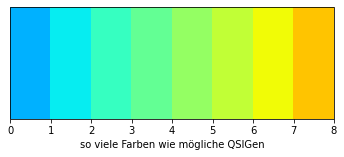

In [148]:
# diskrete CM für die QSIGs vorbelegen
# ------------------------------------

# Anz. EGn
anzEG=len(qsCols)
anzQSIG_moeglich=int(math.pow(2,anzEG))

# kont. CM ist Ausgangsbasis
cMap=plt.cm.get_cmap('jet') # kont.: hasattr(cMap,'from_list')
# Farben  
randOffset=.3
cmQSIG=cMap.from_list('cmQSIG'
                      , cMap(np.linspace(0+randOffset, 1-randOffset, anzQSIG_moeglich))
                      , anzQSIG_moeglich)

plt.close()
size_DINA6quer=(5.8,4.1)    
fig, ax = plt.subplots(figsize=size_DINA6quer)
fig.subplots_adjust(bottom=0.5)
norm=matplotlib.colors.Normalize(vmin=0, vmax=anzQSIG_moeglich)
cb=matplotlib.colorbar.ColorbarBase(ax, cmap=cmQSIG,norm=norm,orientation='horizontal')
cb.set_label('so viele Farben wie mögliche QSIGen')    
plt.show()

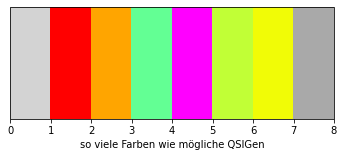

In [149]:
# einzelne Farben darin ersetzen

def f(cMap,idxCol,newCol):    
    colors=cMap(np.arange(cMap.N,dtype=int)) # alle Farben
    newCol=list(matplotlib.colors.to_rgb(newCol))    
    newCol.extend([1.])
    colors[idxCol]=newCol
    return matplotlib.colors.ListedColormap(colors)  

# Farbe der 0-Einspeisergruppe  festlegen
ZColor='lightgray'
cmQSIG=f(cmQSIG,int('000',2),ZColor)

# Farbe der 1-Einspeisergruppe  festlegen
ZColor='darkgray'
cmQSIG=f(cmQSIG,int('111',2),ZColor)

# Farbe der A-Einspeisergruppe  festlegen -1.
AColColor='magenta'#'mediumorchid'
cmQSIG=f(cmQSIG,int('100',2),AColColor)
# 2.
NAColor='orange'
cmQSIG=f(cmQSIG,int('010',2),NAColor)
# 3.
cmQSIG=f(cmQSIG,int('001',2),'r')



plt.close()
size_DINA6quer=(5.8,4.1)    
fig, ax = plt.subplots(figsize=size_DINA6quer)
fig.subplots_adjust(bottom=0.5)
norm=matplotlib.colors.Normalize(vmin=0, vmax=anzQSIG_moeglich)
cb=matplotlib.colorbar.ColorbarBase(ax, cmap=cmQSIG,norm=norm,orientation='horizontal')
cb.set_label('so viele Farben wie mögliche QSIGen')    
plt.show()



In [150]:
vROHRexp['qsigInt']=vROHRexp.apply(lambda row: int(row.qsigStr,2) ,axis=1)  
vROHRexp['qsigInt'].unique() # der Wertebereich ist weder zwingend lückenlos, 
#noch hat er zwingend soviele Ausprägungen wie die CM Farben hat

array([4, 2, 6, 1, 3], dtype=int64)

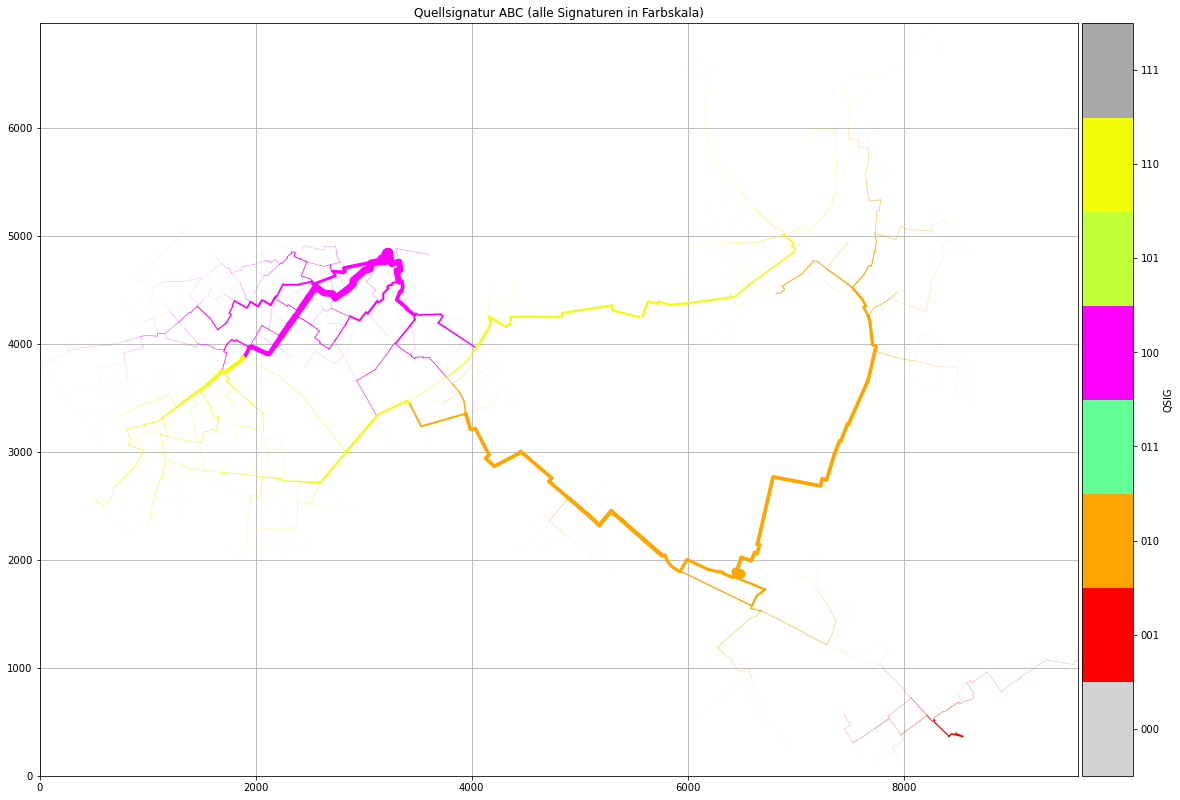

In [151]:
import numpy as np
plt.close()
size_DINA3quer=(16.5, 11.7) 
dpiSize=72
fig=plt.figure(figsize=size_DINA3quer,dpi=dpiSize)         
gs = gridspec.GridSpec(1, 1)

# ---
# 
axNfd = fig.add_subplot(gs[0])              
Rm.Rm.pltNetPipes(vROHRexp
    ,query="CONT_ID == '1001'"
    ,fmask=lambda row: True if row.KVR_i=='1' and row.KVR_k=='1' else False 
    ,pAx=axNfd
    ,pAttributeColorMap=cmQSIG
    ,pAttribute='qsigInt'
    ,CBBinBounds=[idx for idx in range(anzQSIG_moeglich+1)]
   
    ,pAttrLineSize='QAbs'
    ,sort_values_by=['QAbs'] 
    ,sort_values_ascending=True      
    ,pAttrLineSizeFactor=3*1./(vROHRexp['QAbs'].std()*2.)   
                  
    # es werden so viele Ticks generiert wie Bounds Einträge hat - 1 mehr als Anzahl Farben
    # wir wollen weniger Ticks (so viele wie Anzahl Farben) und diese in der Mitte  
    ,CBTicks=[idx+.5 for idx in range(anzQSIG_moeglich)]
    ,CBTickLabels=["{0:b}".format(idx).zfill(anzEG) for idx in range(anzQSIG_moeglich)]     
    ,CBLabel='QSIG'
    )    
txt=axNfd.set_title('Quellsignatur ABC (alle Signaturen in Farbskala)')



gs.tight_layout(fig)
plt.show()

In [152]:
# nur die Farben holen, welche vorkommen
# alle Farben holen, welche die cmap hat
ccolors = plt.get_cmap(cmQSIG)(np.arange(plt.get_cmap(cmQSIG).N,dtype=int))
# die gewuenschten Farben extrahieren   

QSIGBzLst=sorted([int(idx,2) for idx in vROHRexp['qsigStr'].unique()])
ccolors=[ccolors[idx] for idx in QSIGBzLst]
cmQSIGBz = matplotlib.colors.ListedColormap(ccolors) 
QSIGBzLst

[1, 2, 3, 4, 6]

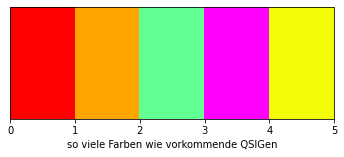

In [153]:
plt.close()
size_DINA6quer=(5.8,4.1)    
fig, ax = plt.subplots(figsize=size_DINA6quer)
fig.subplots_adjust(bottom=0.5)
norm=matplotlib.colors.Normalize(vmin=0, vmax=len(QSIGBzLst))
cb=matplotlib.colorbar.ColorbarBase(ax, cmap=cmQSIGBz,norm=norm,orientation='horizontal')
cb.set_label('so viele Farben wie vorkommende QSIGen')    
plt.show()

In [154]:
QSIGBzLstIdx=[idx for idx in range(len(QSIGBzLst))]
QSIGBzLstIdx

[0, 1, 2, 3, 4]

In [155]:
vROHRexp['qsigIntBzIdx']=vROHRexp.apply(lambda row: QSIGBzLst.index(row.qsigInt)  ,axis=1) 

In [156]:
vROHRexp['qsigIntBzIdx'].unique()
# der Wertebereich ist jetzt lückenlos und hat soviele voneinander verschiedene Ausprägungen wie die CM Farben hat

array([3, 1, 4, 0, 2], dtype=int64)

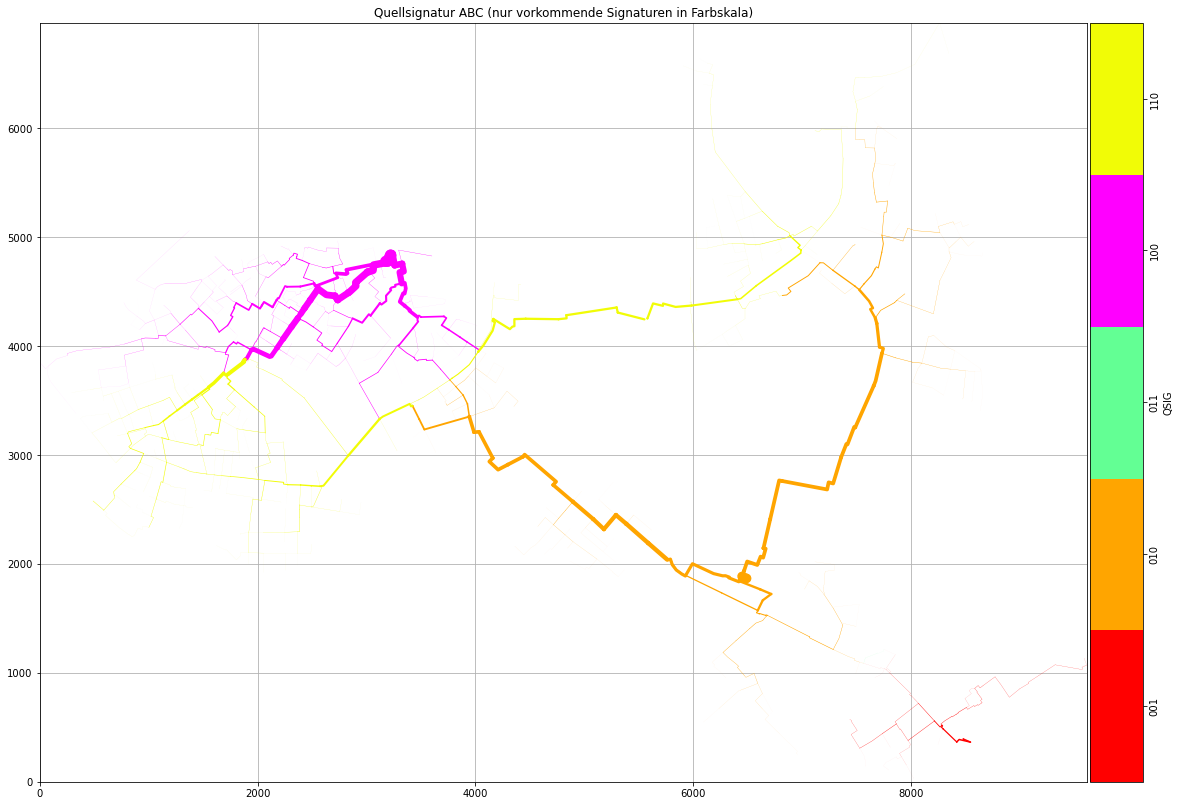

In [157]:

plt.close()
size_DINA3quer=(16.5, 11.7) 
dpiSize=72
fig=plt.figure(figsize=size_DINA3quer,dpi=dpiSize)         
gs = gridspec.GridSpec(1, 1)

ticksLabels=["{0:b}".format(QSIGBzLst[idx]).zfill(anzEG) for idx in range(plt.get_cmap(cmQSIGBz).N)]

# ---
# 
axNfd = fig.add_subplot(gs[0])              
Rm.Rm.pltNetPipes(vROHRexp
    ,query="CONT_ID == '1001'"
    ,fmask=lambda row: True if row.KVR_i=='1' and row.KVR_k=='1' else False 
    ,pAx=axNfd
    ,pAttributeColorMap=cmQSIGBz
    ,pAttribute='qsigIntBzIdx'  
                  
    ,CBBinBounds=[idx for idx in range(len(vROHRexp['qsigIntBzIdx'].unique())+1)]                  
   
    ,pAttrLineSize='QAbs'
    ,sort_values_by=['QAbs'] 
    ,sort_values_ascending=True      
    ,pAttrLineSizeFactor=3*1./(vROHRexp['QAbs'].std()*2.)        
                  
    # es werden so viele Ticks generiert wie Bounds Einträge hat - 1 mehr als Anzahl Farben
    # wir wollen weniger Ticks (so viele wie Anzahl Farben) und diese in der Mitte  
    ,CBTicks=[idx+.5 for idx in range(len(vROHRexp['qsigIntBzIdx'].unique()))]
    ,CBTickLabels=["dummy" for idx in range(len(vROHRexp['qsigIntBzIdx'].unique()))]                       
                     
    ,CBLabel='QSIG'
    )    
txt=axNfd.set_title('Quellsignatur ABC (nur vorkommende Signaturen in Farbskala)')

ax = plt.gca() 
#print(ax.get_yticks())
#print(ax.get_yticklabels())

newTickLabels=len(vROHRexp['qsigIntBzIdx'].unique())*[""]

df=vROHRexp[['qsigIntBzIdx','qsigStr','qsigRank_L','qsigRank_sumL']].drop_duplicates().reset_index()

for index, row in df.iterrows():
    idx2=row['qsigIntBzIdx']
    qsigStr=row['qsigStr']
    newTickLabels[idx2]=qsigStr
   
ax.set_yticklabels(newTickLabels,rotation=90,va='center',ha='left')


gs.tight_layout(fig)
plt.show()

# Abschlussarbeiten 

## Anleitung Doc-Gen

Version-String in conf.py and setup.py

sphinx-build -b html . _build

sphinx-build -b latex . _build 

in _build:

pdflatex --extra-mem-bot=10000000 PT3S.tex

erzeugt PT3S.PDF; kopieren nach ..

## Anmerkungen

z.B. PDF Doc-Gen derzeit nur um die grundsätzliche Generierbarkeit zu prüfen: d.h. ob die Kommentar- und Testbereiche redaktionell soll aufgebaut sind, dass ein Generator damit zurecht kommt; die Einstiegs-Doc ist dieses Notebook

# Deploy

pip install twine


In [1]:
!python setup.py clean sdist 

running clean
running sdist
running egg_info
writing PT3S.egg-info\PKG-INFO
writing dependency_links to PT3S.egg-info\dependency_links.txt
writing top-level names to PT3S.egg-info\top_level.txt
reading manifest file 'PT3S.egg-info\SOURCES.txt'
writing manifest file 'PT3S.egg-info\SOURCES.txt'
running check
creating PT3S-90.11.1.31.dev1
creating PT3S-90.11.1.31.dev1\testdata
creating PT3S-90.11.1.31.dev1\testdata09
creating PT3S-90.11.1.31.dev1\testdata09\WDGPipe
creating PT3S-90.11.1.31.dev1\testdata09\WDGPipe\B1
creating PT3S-90.11.1.31.dev1\testdata09\WDGPipe\B1\V0
creating PT3S-90.11.1.31.dev1\testdata09\WDGPipe\B1\V0\BZ1
creating PT3S-90.11.1.31.dev1\testdata09\WDLocalHeatingNetwork
creating PT3S-90.11.1.31.dev1\testdata09\WDLocalHeatingNetwork\B1
creating PT3S-90.11.1.31.dev1\testdata09\WDLocalHeatingNetwork\B1\V0
creating PT3S-90.11.1.31.dev1\testdata09\WDLocalHeatingNetwork\B1\V0\BZ1
creating PT3S-90.11.1.31.dev1\testdata09\WDOneLPipe
creating PT3S-90.11.1.31.dev1\testdata09\WDO

In [5]:
#!twine upload -u PT3S -p xxx dist/*

Uploading distributions to https://upload.pypi.org/legacy/
Uploading PT3S-90.11.1.31.dev1.tar.gz

  0%|          | 0.00/10.2M [00:00<?, ?B/s]
  0%|          | 8.00k/10.2M [00:00<08:50, 20.2kB/s]
  1%|          | 80.0k/10.2M [00:00<06:13, 28.5kB/s]
  1%|          | 96.0k/10.2M [00:00<04:44, 37.4kB/s]
  2%|1         | 184k/10.2M [00:00<03:21, 52.4kB/s] 
  4%|3         | 368k/10.2M [00:00<02:20, 73.8kB/s]
  7%|7         | 736k/10.2M [00:00<01:35, 104kB/s] 
  8%|8         | 872k/10.2M [00:01<01:11, 137kB/s]
 12%|#1        | 1.21M/10.2M [00:01<00:49, 192kB/s]
 13%|#3        | 1.35M/10.2M [00:01<00:35, 259kB/s]
 15%|#4        | 1.49M/10.2M [00:01<00:27, 336kB/s]
 16%|#6        | 1.68M/10.2M [00:01<00:20, 448kB/s]
 18%|#7        | 1.80M/10.2M [00:01<00:15, 555kB/s]
 19%|#9        | 1.95M/10.2M [00:01<00:12, 682kB/s]
 20%|##        | 2.09M/10.2M [00:02<00:10, 811kB/s]
 22%|##1       | 2.23M/10.2M [00:02<00:08, 936kB/s]
 23%|##3       | 2.38M/10.2M [00:02<00:07, 1.05MB/s]
 25%|##4       | 2.52M

# Develop

In [1]:
### ggf. Rechte erforderlich (siehe oben):
!pip install -e .

Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///C:/Users/wolters.3S/source/repos/PT3S
  Running setup.py develop for PT3S


due to ...\Lib\site-packages\PT3S.egg-link

import PT3S or from PT3S import ...

will work (if PythonShell is executed .. PT3SSourcecodeDir)

and point to _local PT3SSourcecodeDir

Repository: https://github.com/aw3s/PT3S.git